# Simulation results analysis — MPM only

Reads `Input_Results_redo.csv`. All plots use the corrected MPM `|MPM - Mean|`.

1. Per Hs pair: MPM vs Tp, 3 DOFs, averaged over directions, one line per damping case.
2. Per Hs pair: MPM vs Tp, 3 DOFs, low damping only, one line per direction.
3. Per Hs: % MPM difference vs `low`, 3 DOFs side by side.
4. Damping effectiveness vs Hs, averaged over Tp and direction.
5. Damping effectiveness vs Tp, averaged over Hs and direction.
6. Direct linhigh-vs-quadhigh comparison vs Hs and vs Tp.
7. `average` damping vs low, linhigh and quadhigh (3 DOFs × 3 alternatives).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

In [2]:
df = pd.read_csv('Simulation_output_redo.csv')

for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm',   'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg', 'drop_dirs': []},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg', 'drop_dirs': [0, 180]},
]

DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

HS_VALUES = sorted(df['Hs'].unique())
DIRECTIONS = sorted(df['Direction'].unique())

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def filter_dirs(sub, dof):
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

def hs_pairs(values):
    """Group Hs values into pairs of 2 for side-by-side plotting."""
    return [values[i:i+2] for i in range(0, len(values), 2)]

# Groups of Hs values plotted side by side. Hs 4, 6, 8 share a figure;
# the higher-Hs subplots are narrower because they only span Tp 9-12.
HS_GROUPS = [[1, 2], [4, 6, 8]]

def tp_count(df, hs):
    """Number of distinct Tp values for this Hs (drives subplot width)."""
    return df[df['Hs'] == hs]['Tp'].nunique()

print('Hs values:', HS_VALUES)
print('Directions:', DIRECTIONS)

Hs values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]


## 1. MPM vs Tp, averaged over directions — Hs grouped (4,6,8 share a figure)

3 rows (DOFs) × 2 columns (Hs), one line per damping case.

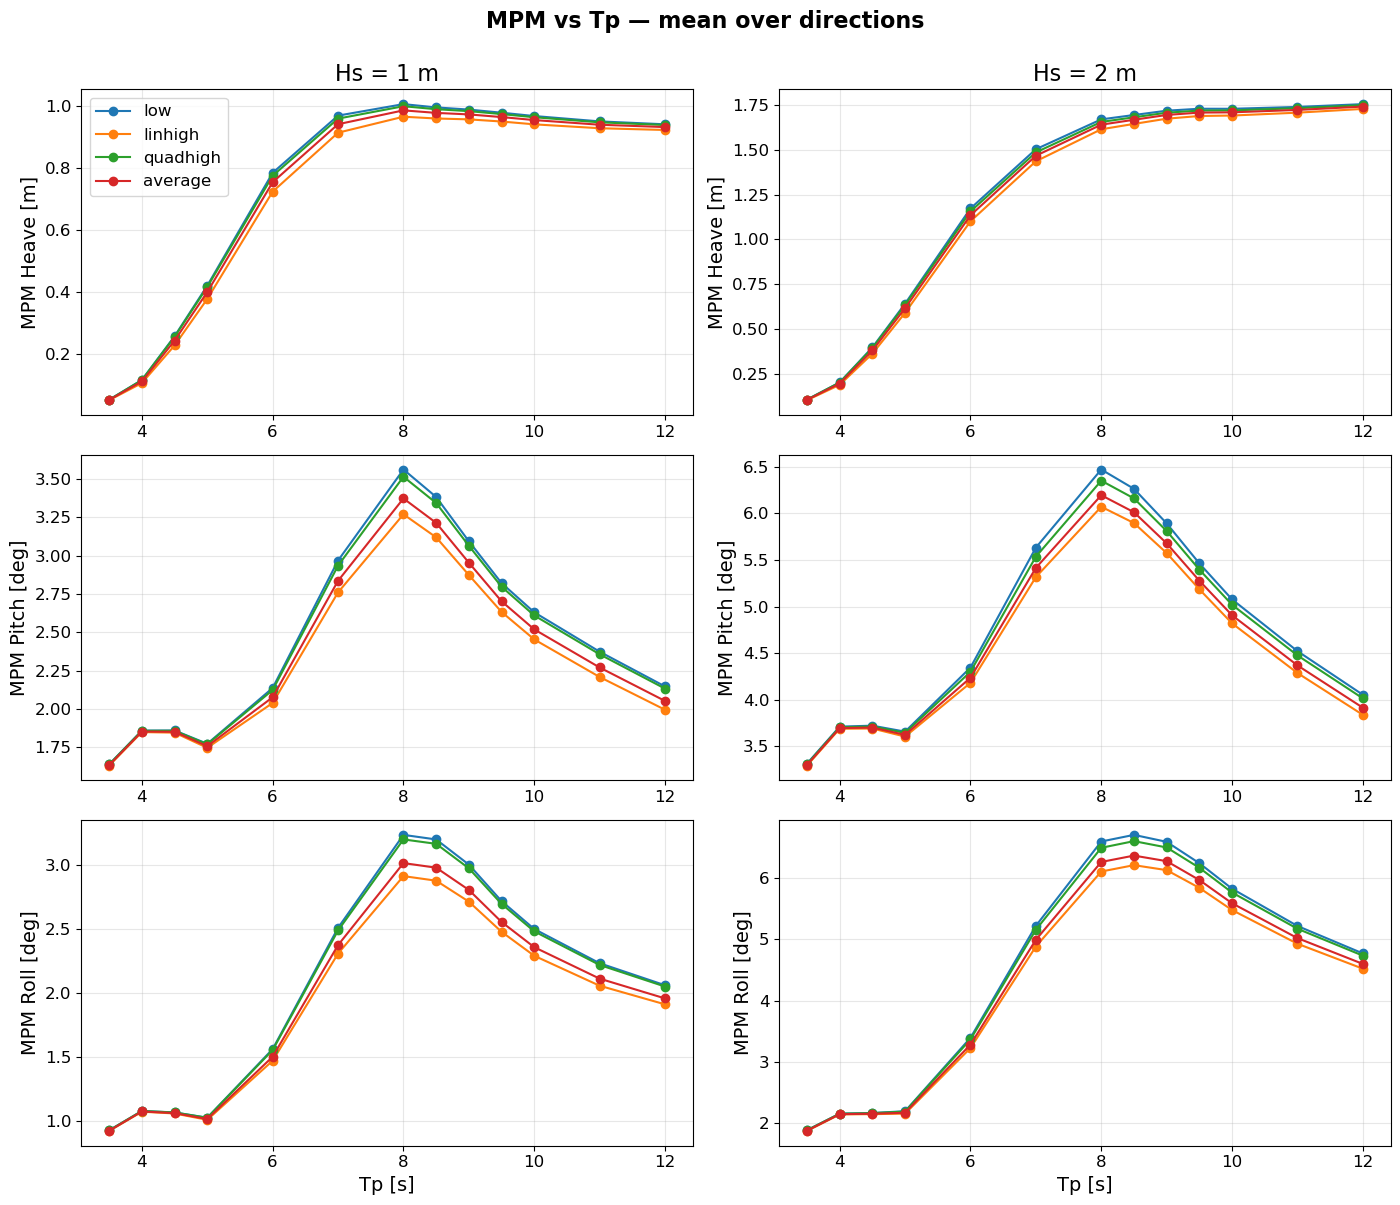

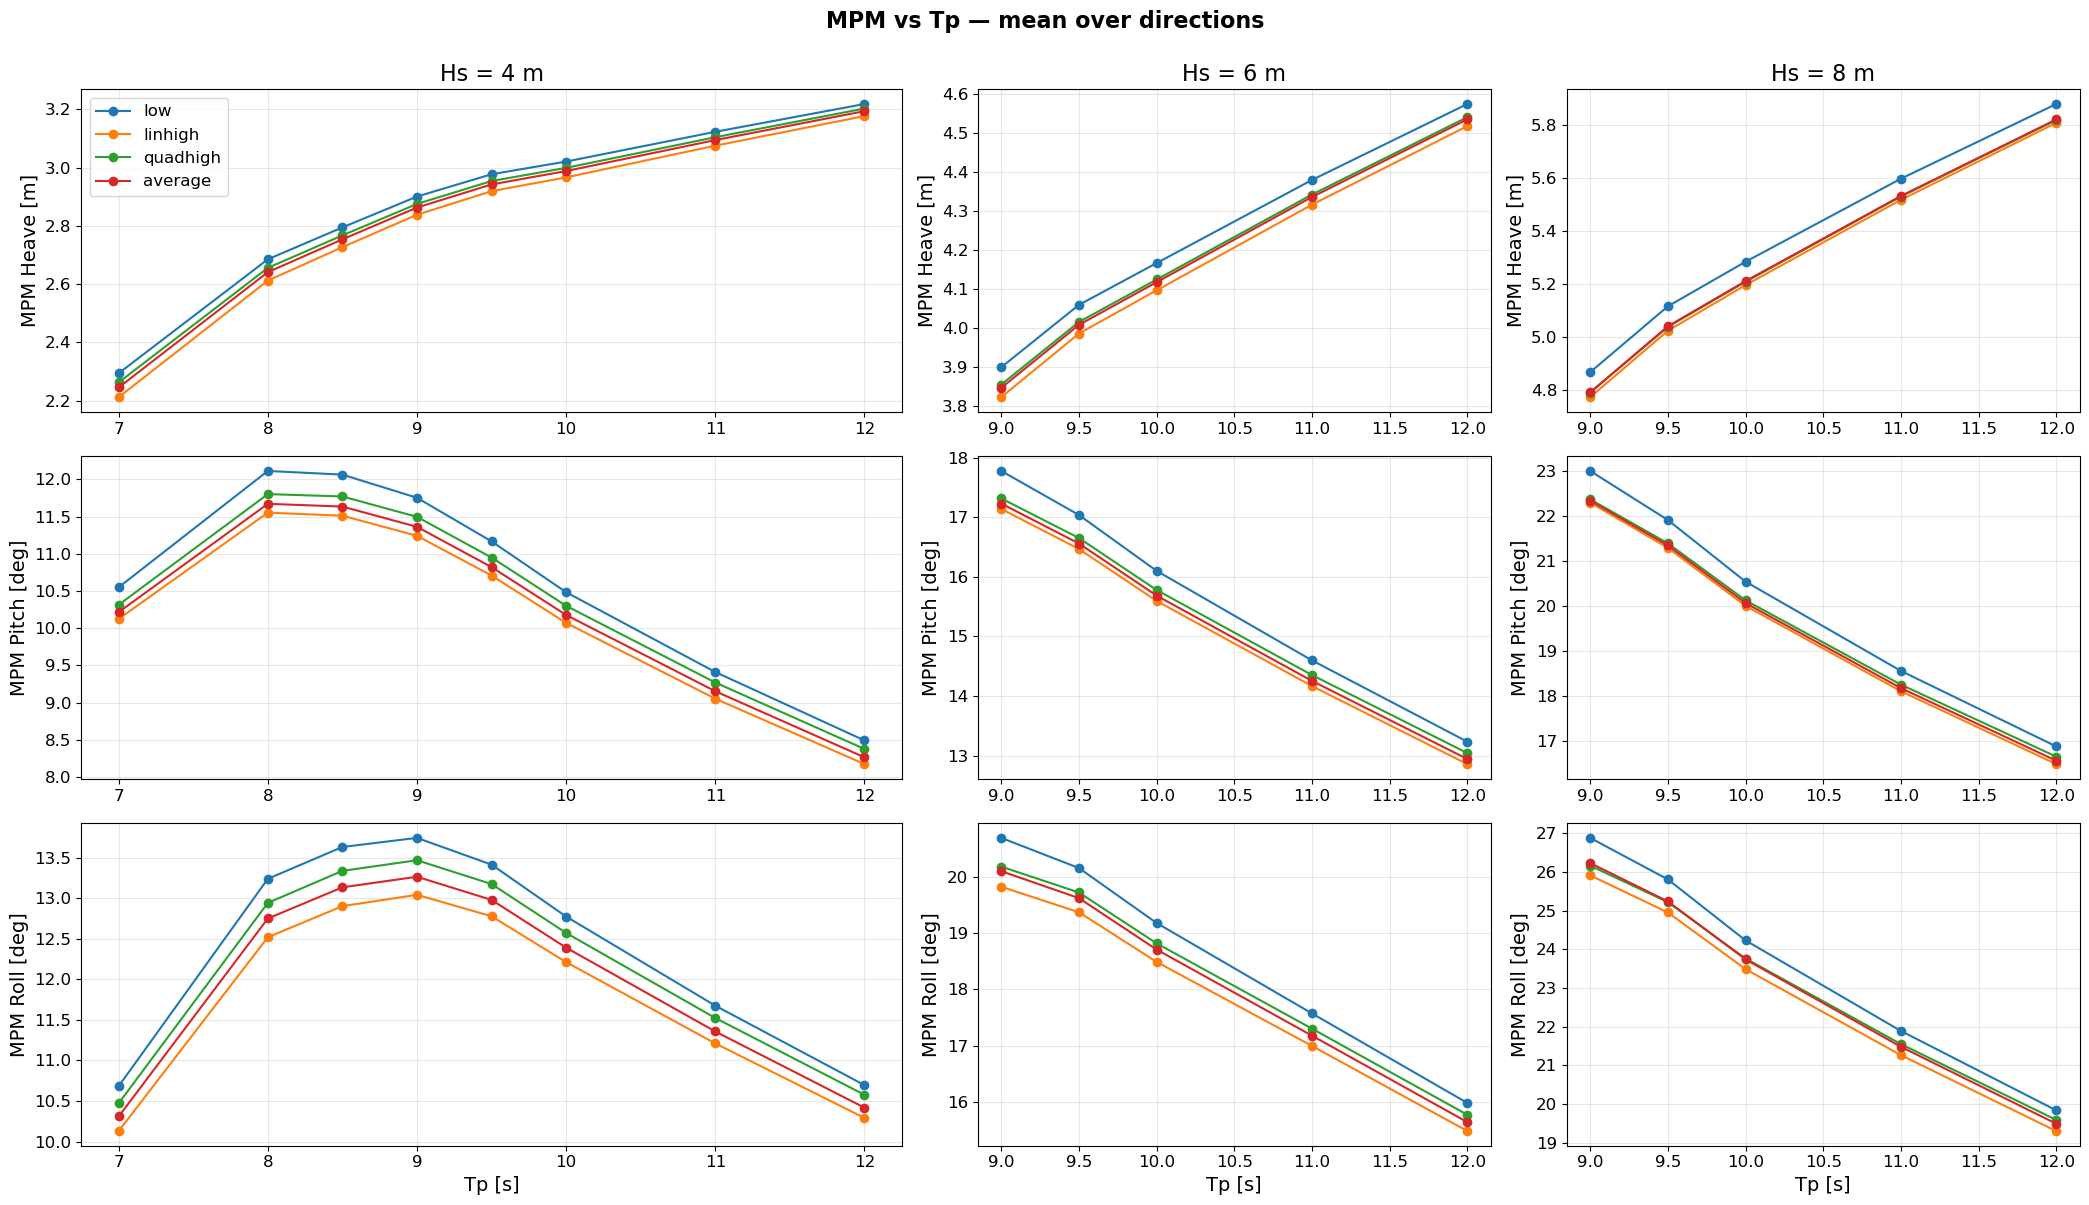

In [3]:
for group in HS_GROUPS:
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[df['Hs'] == hs]
        for r, dof in enumerate(DOFS):
            sub_dof = filter_dirs(sub_hs, dof)
            dcol = damping_col(dof['key'])
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for case in DAMPING_CASES:
                sub_case = sub_dof[sub_dof[dcol] == case]
                if sub_case.empty:
                    continue
                grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
                ax.plot(grouped.index, grouped.values, 'o-',
                        label=case, color=DAMPING_COLORS[case])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]', fontsize=LABEL_SIZE)
            if r == 0:
                ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                ax.legend(fontsize=TICK_SIZE)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('MPM vs Tp — mean over directions', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 2. MPM vs Tp per direction (low damping only) — Hs grouped

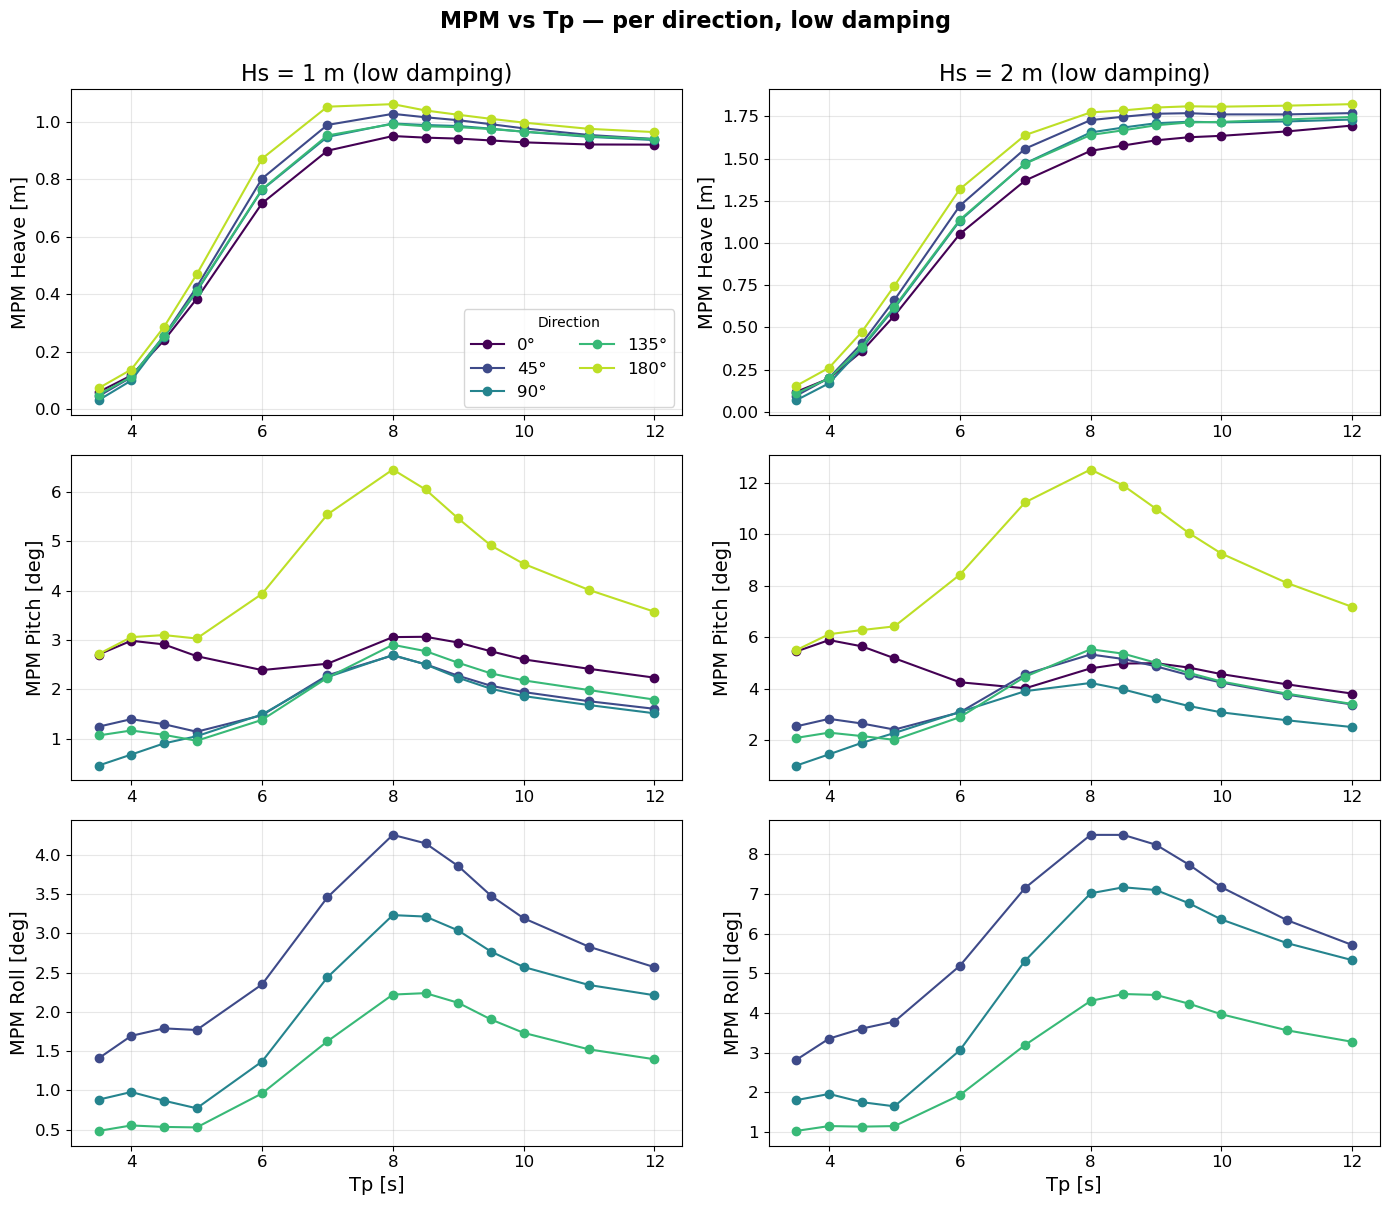

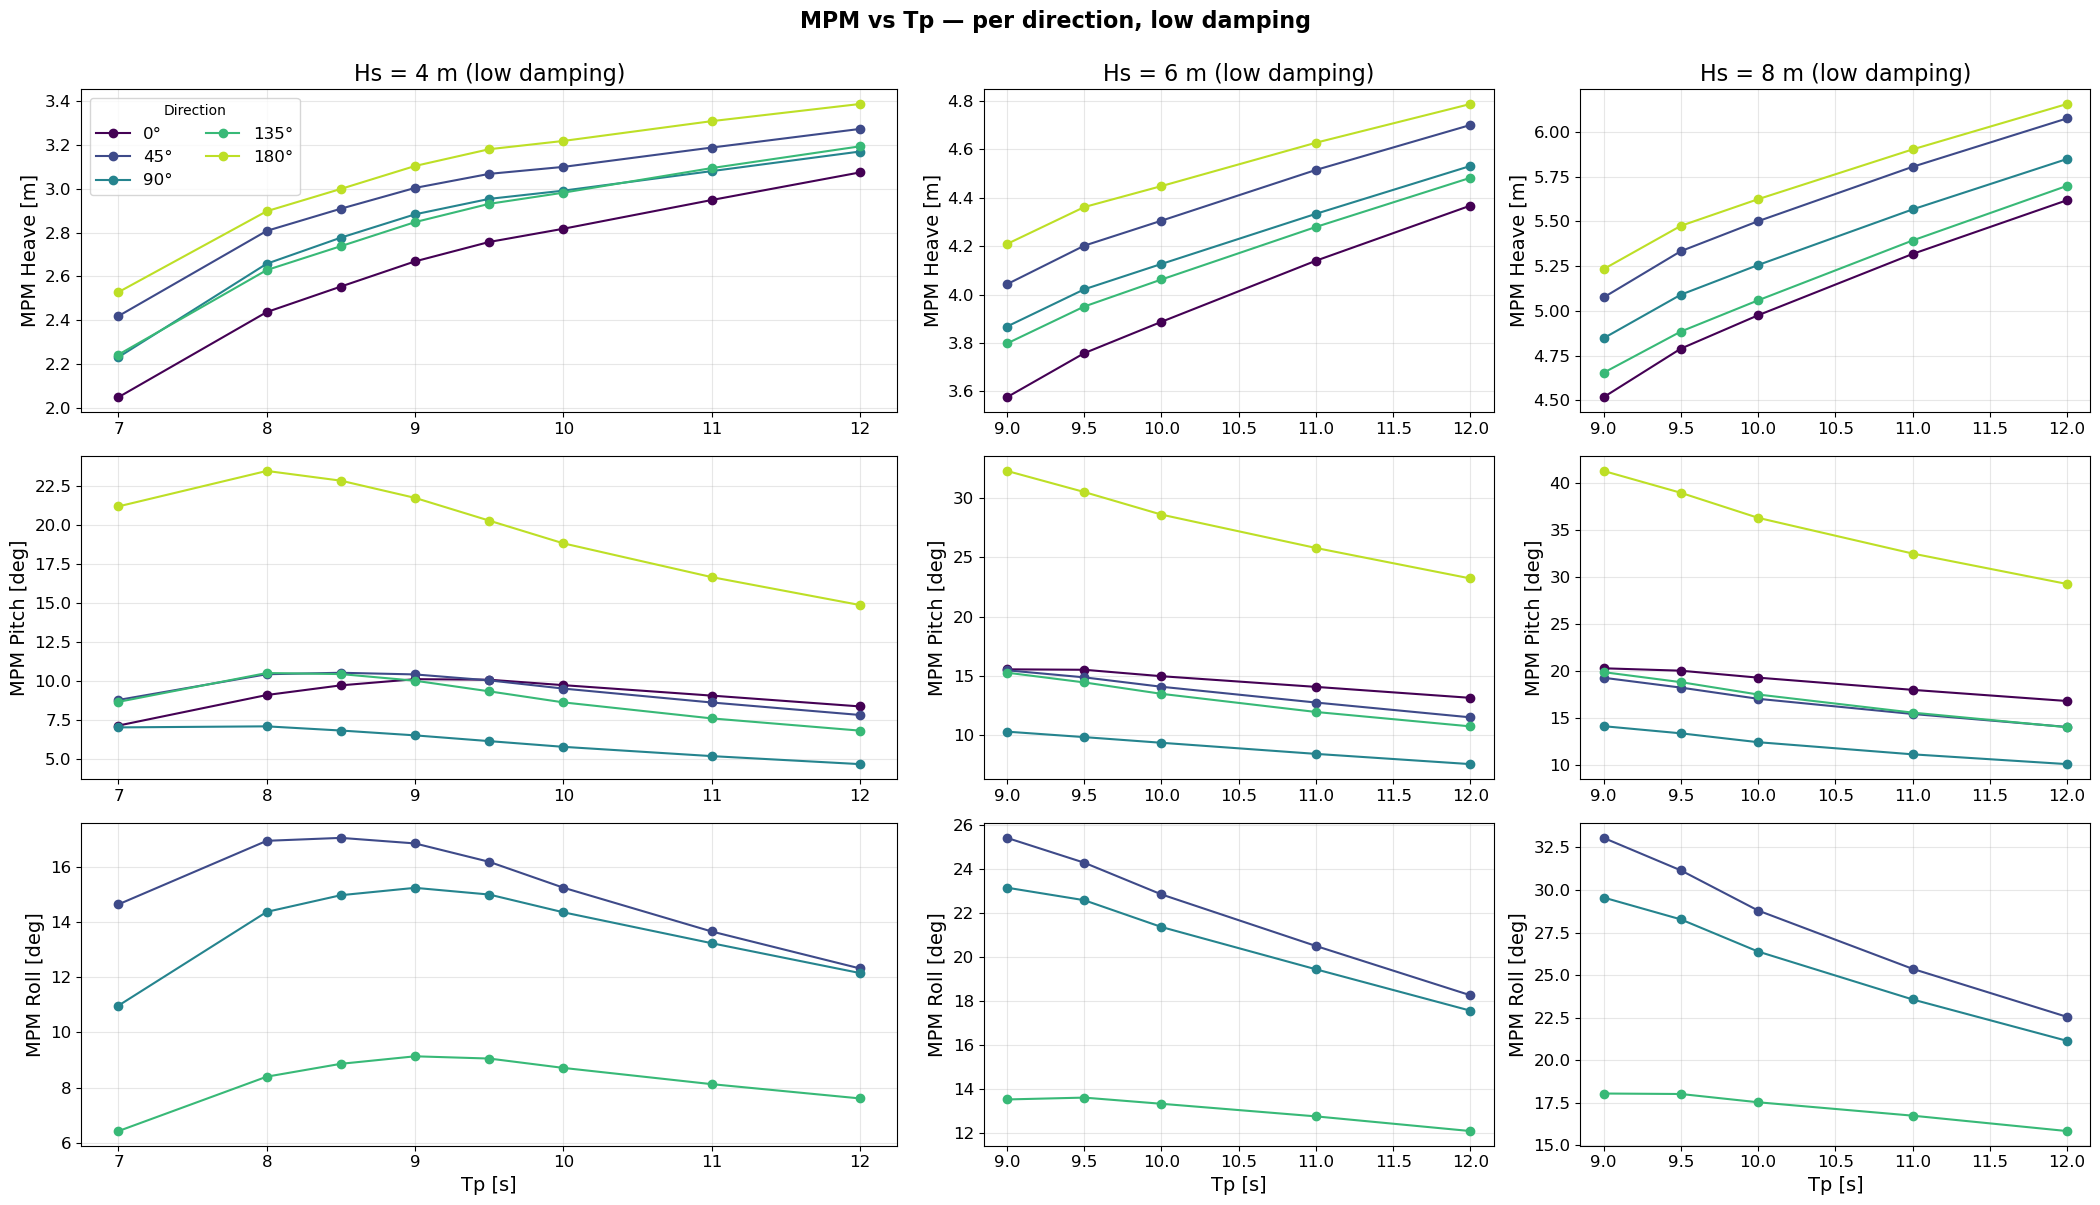

In [4]:
DIR_COLORS = plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS)))

for group in HS_GROUPS:
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]
        for r, dof in enumerate(DOFS):
            sub_dof = filter_dirs(sub_hs, dof)
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for d, direction in enumerate(DIRECTIONS):
                sub_dir = sub_dof[sub_dof['Direction'] == direction].sort_values('Tp')
                if sub_dir.empty:
                    continue
                ax.plot(sub_dir['Tp'], sub_dir[mpm_c], 'o-',
                        label=f'{direction}°', color=DIR_COLORS[d])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]', fontsize=LABEL_SIZE)
            if r == 0:
                ax.set_title(f'Hs = {hs} m (low damping)', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                ax.legend(title='Direction', ncol=2, fontsize=TICK_SIZE)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('MPM vs Tp — per direction, low damping', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 3. Percentage difference vs the `low` case (per Hs)

Computed as `(case − low) / low × 100%` per Tp, after averaging over directions. The `low` case itself is the baseline and is not drawn.

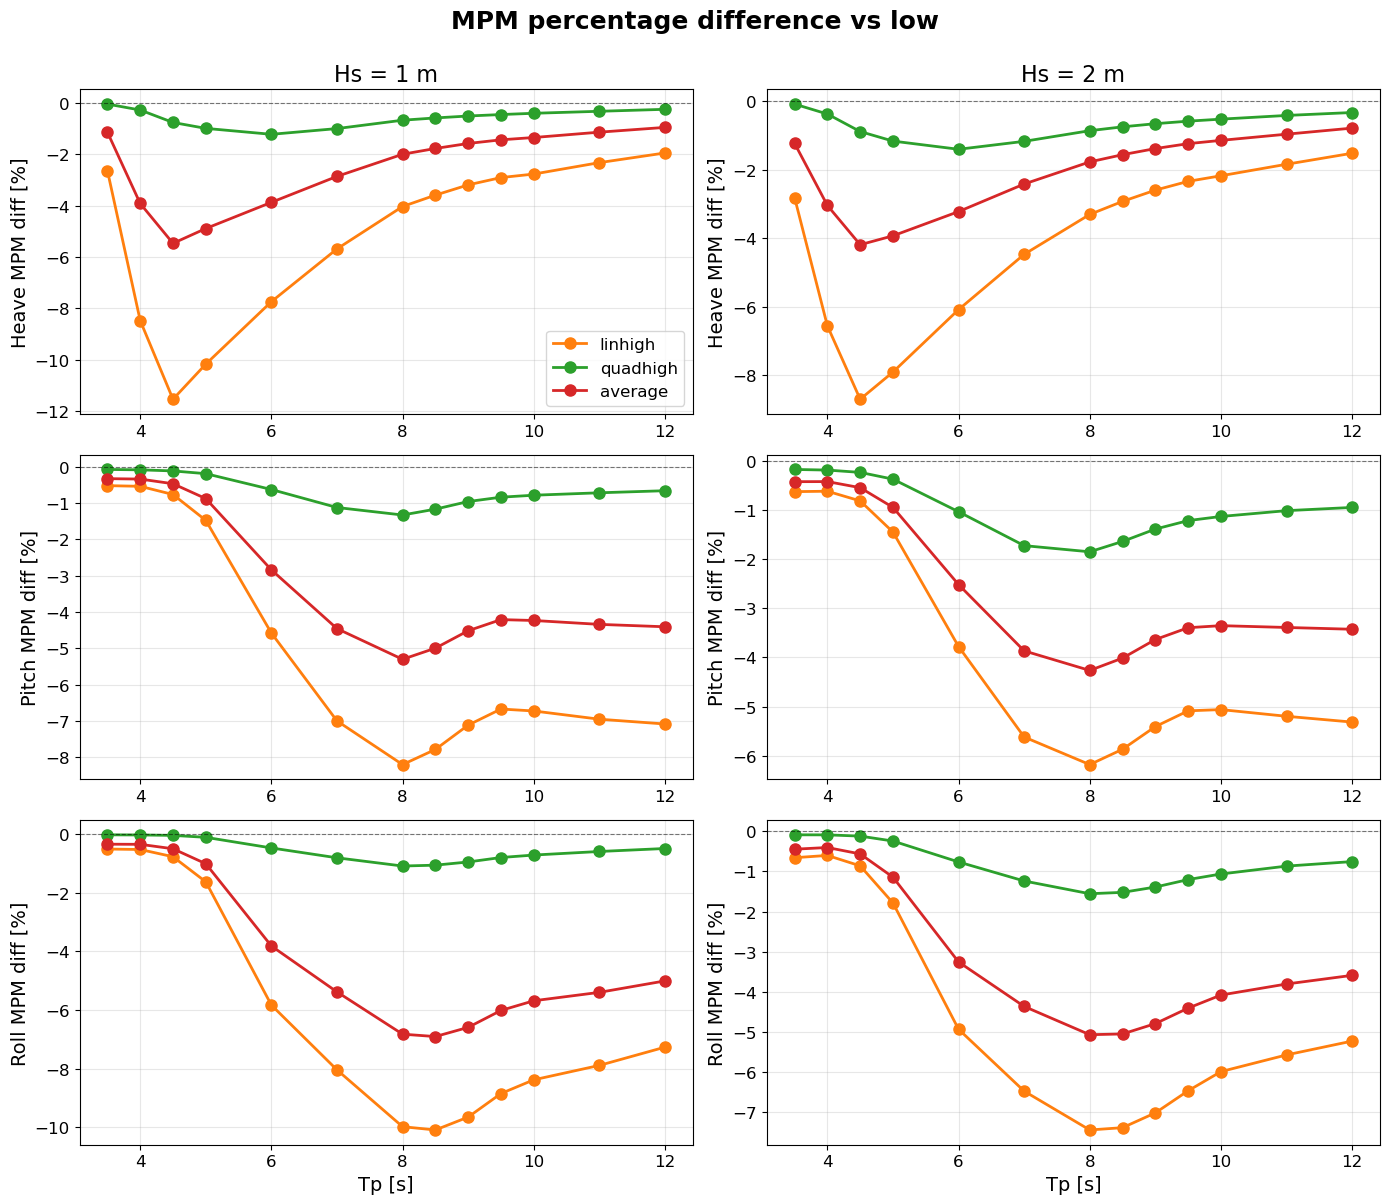

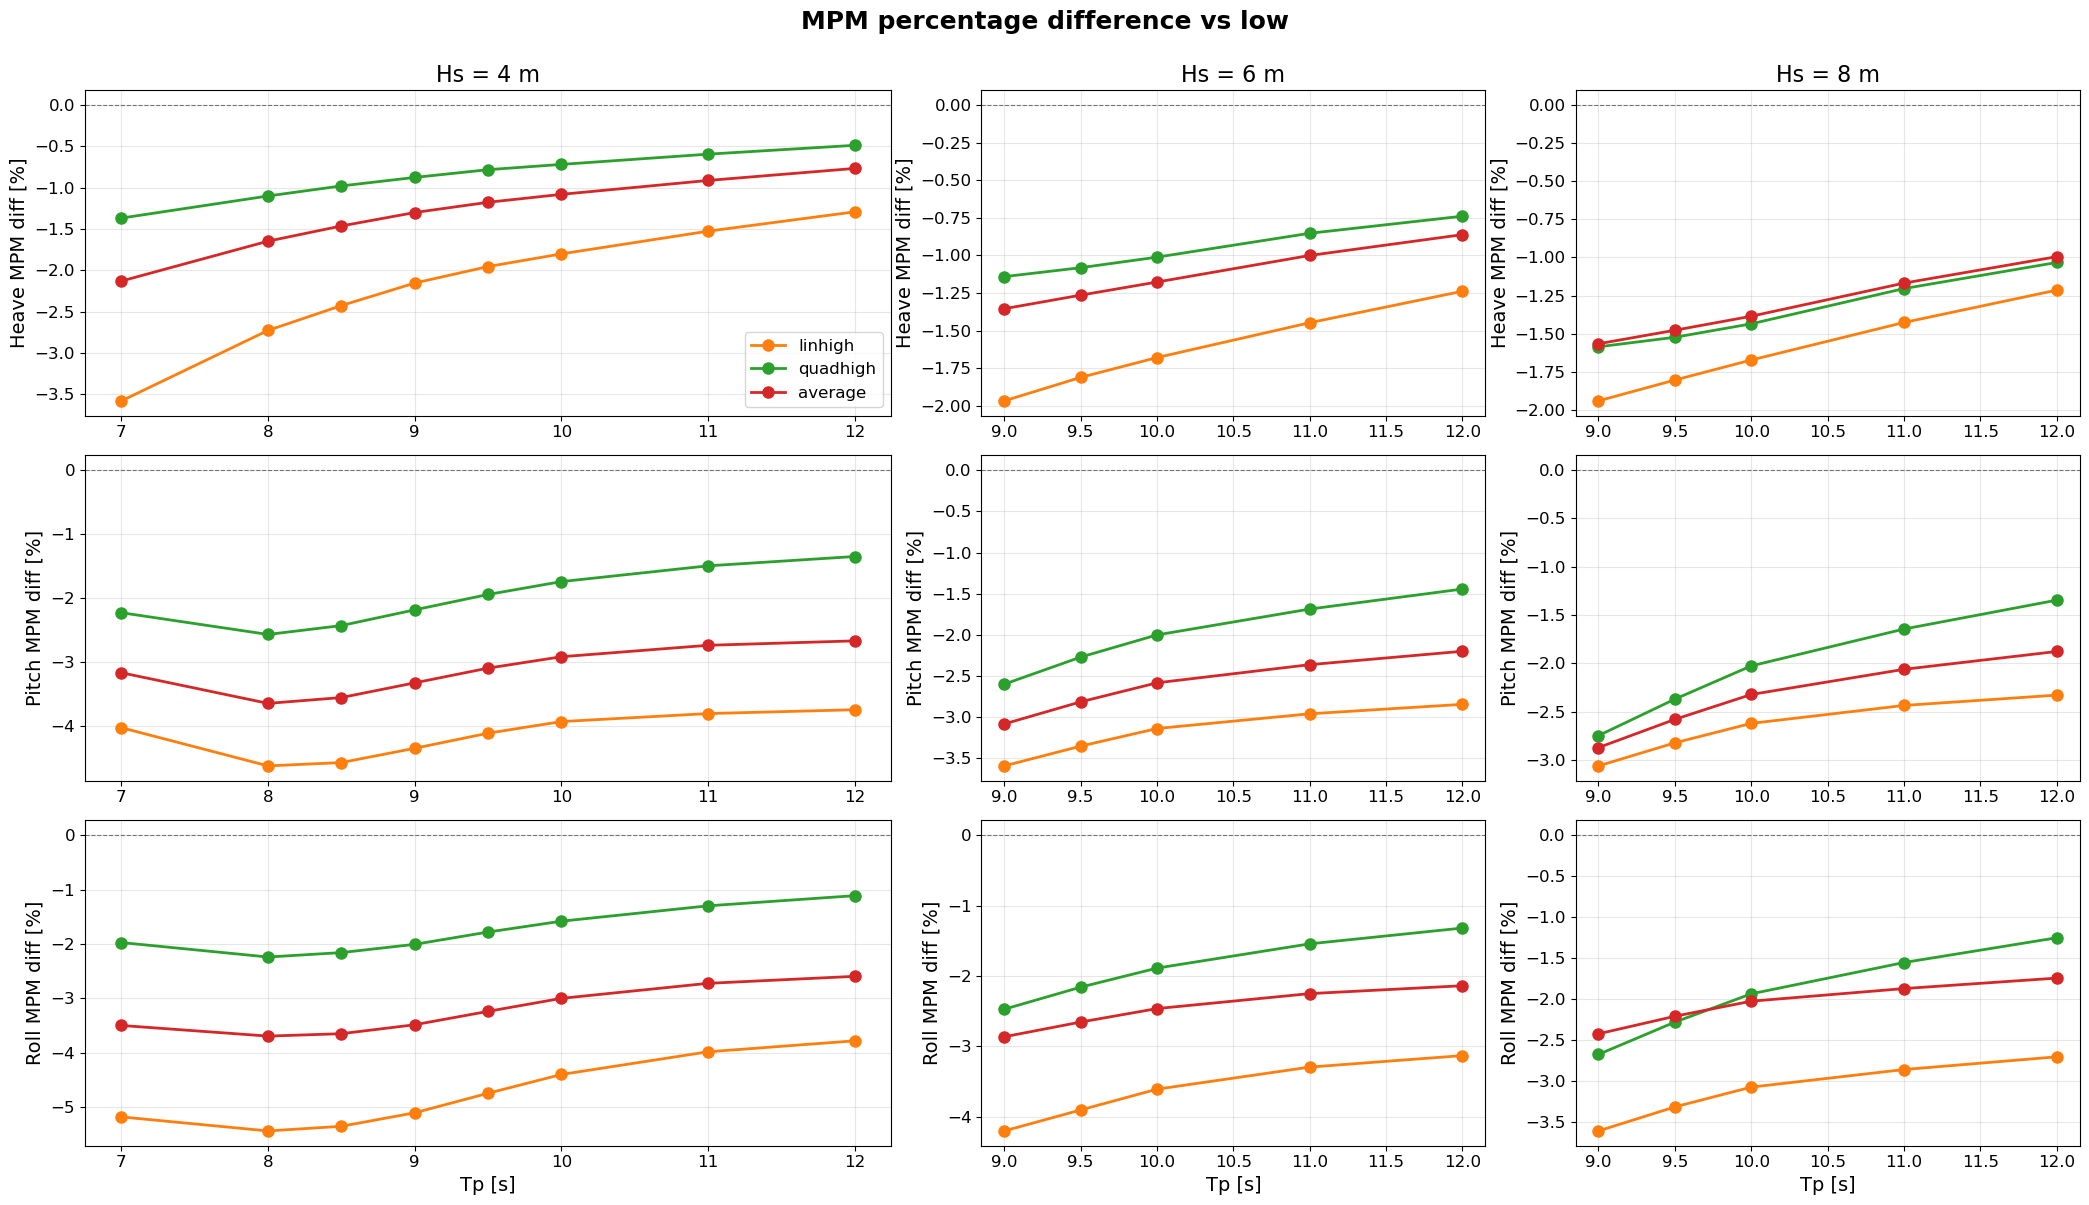

In [5]:
def plot_pct_diff_group(df, group):
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[df['Hs'] == hs]
        for r, dof in enumerate(DOFS):
            ax = axes[r, c]
            sub_dof = filter_dirs(sub_hs, dof)
            dcol = damping_col(dof['key'])
            mpm_c = f'MPM {dof["key"]} corr'

            base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean().sort_index()

            for case in ['linhigh', 'quadhigh', 'average']:
                sub_case = sub_dof[sub_dof[dcol] == case]
                if sub_case.empty:
                    continue
                grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
                common = grouped.index.intersection(base.index)
                if len(common) == 0:
                    continue
                pct = (grouped.loc[common] - base.loc[common]) / base.loc[common] * 100
                ax.plot(common, pct, 'o-', label=case,
                        color=DAMPING_COLORS[case], linewidth=2, markersize=8)

            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.set_ylabel(f'{dof["name"]} MPM diff [%]', fontsize=LABEL_SIZE)
            if r == 0:
                ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                ax.legend(fontsize=TICK_SIZE)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('MPM percentage difference vs low',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig

for group in HS_GROUPS:
    plot_pct_diff_group(df, group)
plt.show()

## 4. Effect of damping vs Hs — does quadratic grow with Hs?

For each Hs we compute the MPM reduction wrt the `low` baseline, averaged over Tp and direction:

$$\text{reduction} = \frac{\text{MPM}_\text{case} - \text{MPM}_\text{low}}{\text{MPM}_\text{low}} \times 100\%$$

If quadratic damping becomes more effective at higher Hs, the green line (quadhigh) should drop faster than the orange line (linhigh) as Hs increases.

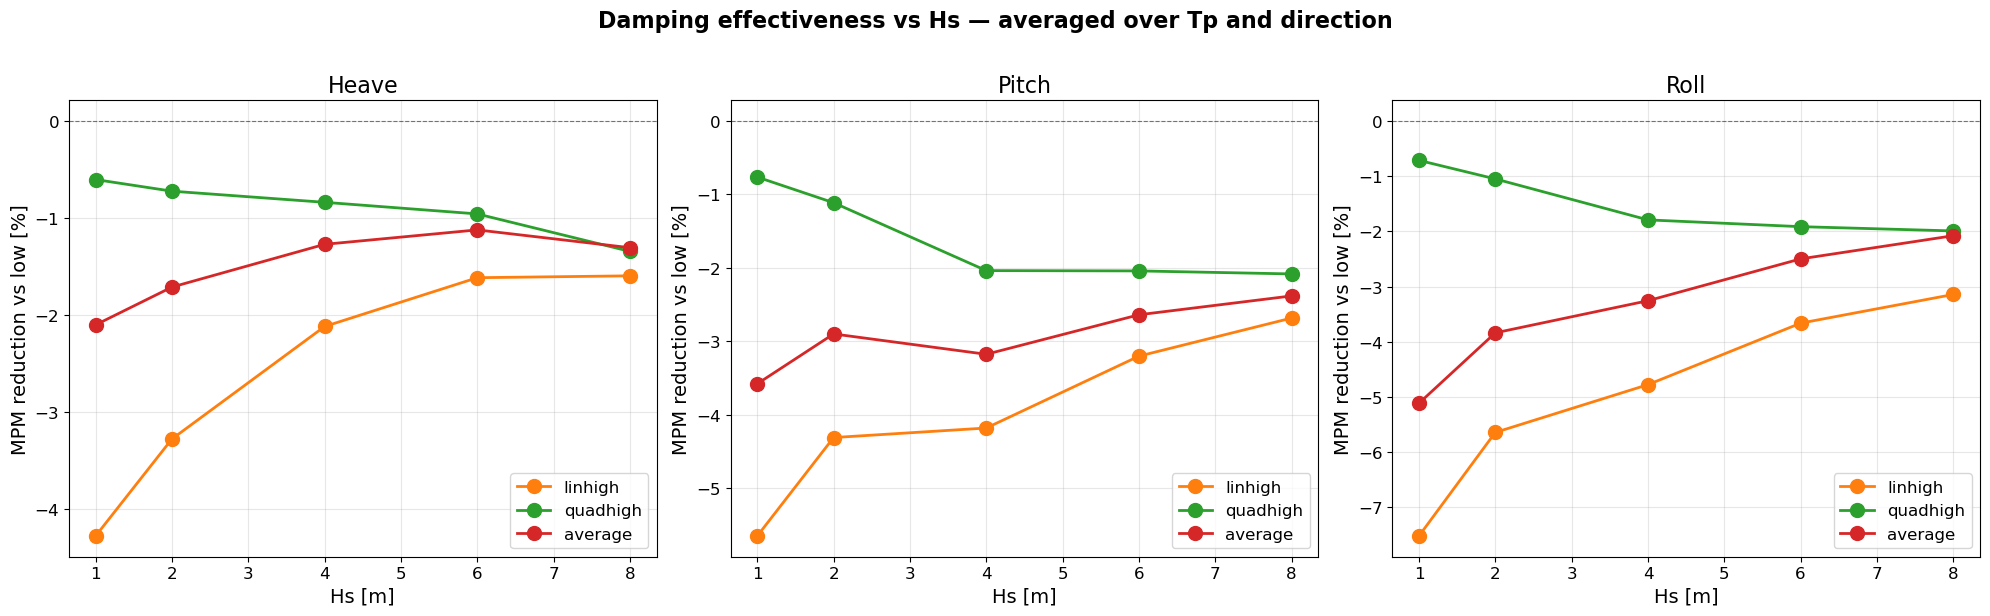

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # baseline: mean over Tp and direction per Hs, for the 'low' case
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel('MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Damping effectiveness vs Hs — averaged over Tp and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Effect of damping vs Tp — does quadratic grow with Tp?

Same idea, but now the % reduction is averaged over Hs and direction, plotted vs Tp.

If quadratic damping becomes more effective at higher Tp, the green line should drop faster as Tp increases.

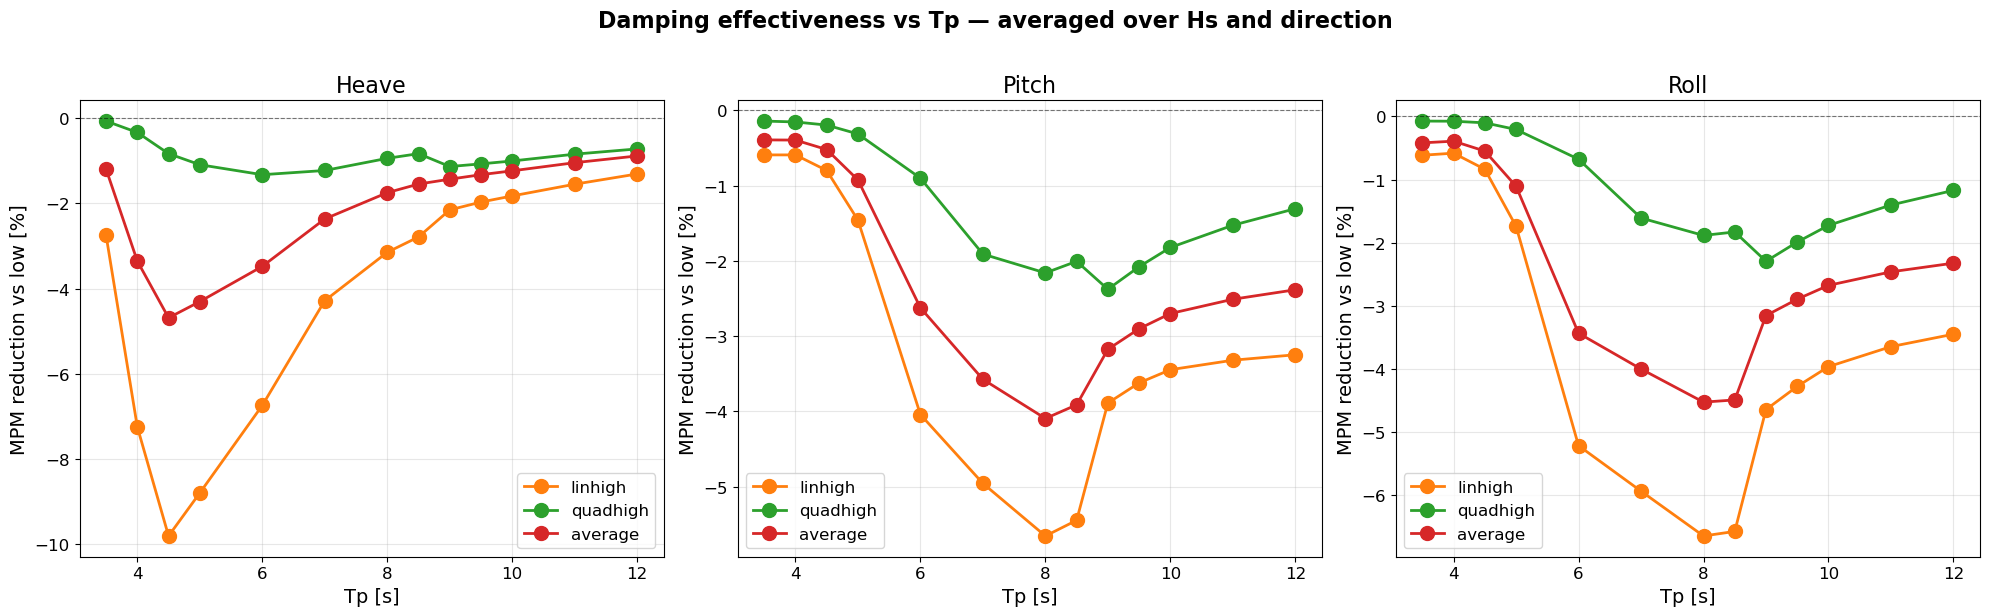

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
    ax.set_ylabel('MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Damping effectiveness vs Tp — averaged over Hs and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Direct quadratic-vs-linear comparison

Two panels per DOF: % MPM reduction vs `low`, plotted against Hs (left) and Tp (right). Only `linhigh` and `quadhigh` are shown, so the crossover is visible. The claim holds when `quadhigh` (green) drops below `linhigh` (orange) as Hs or Tp grows.

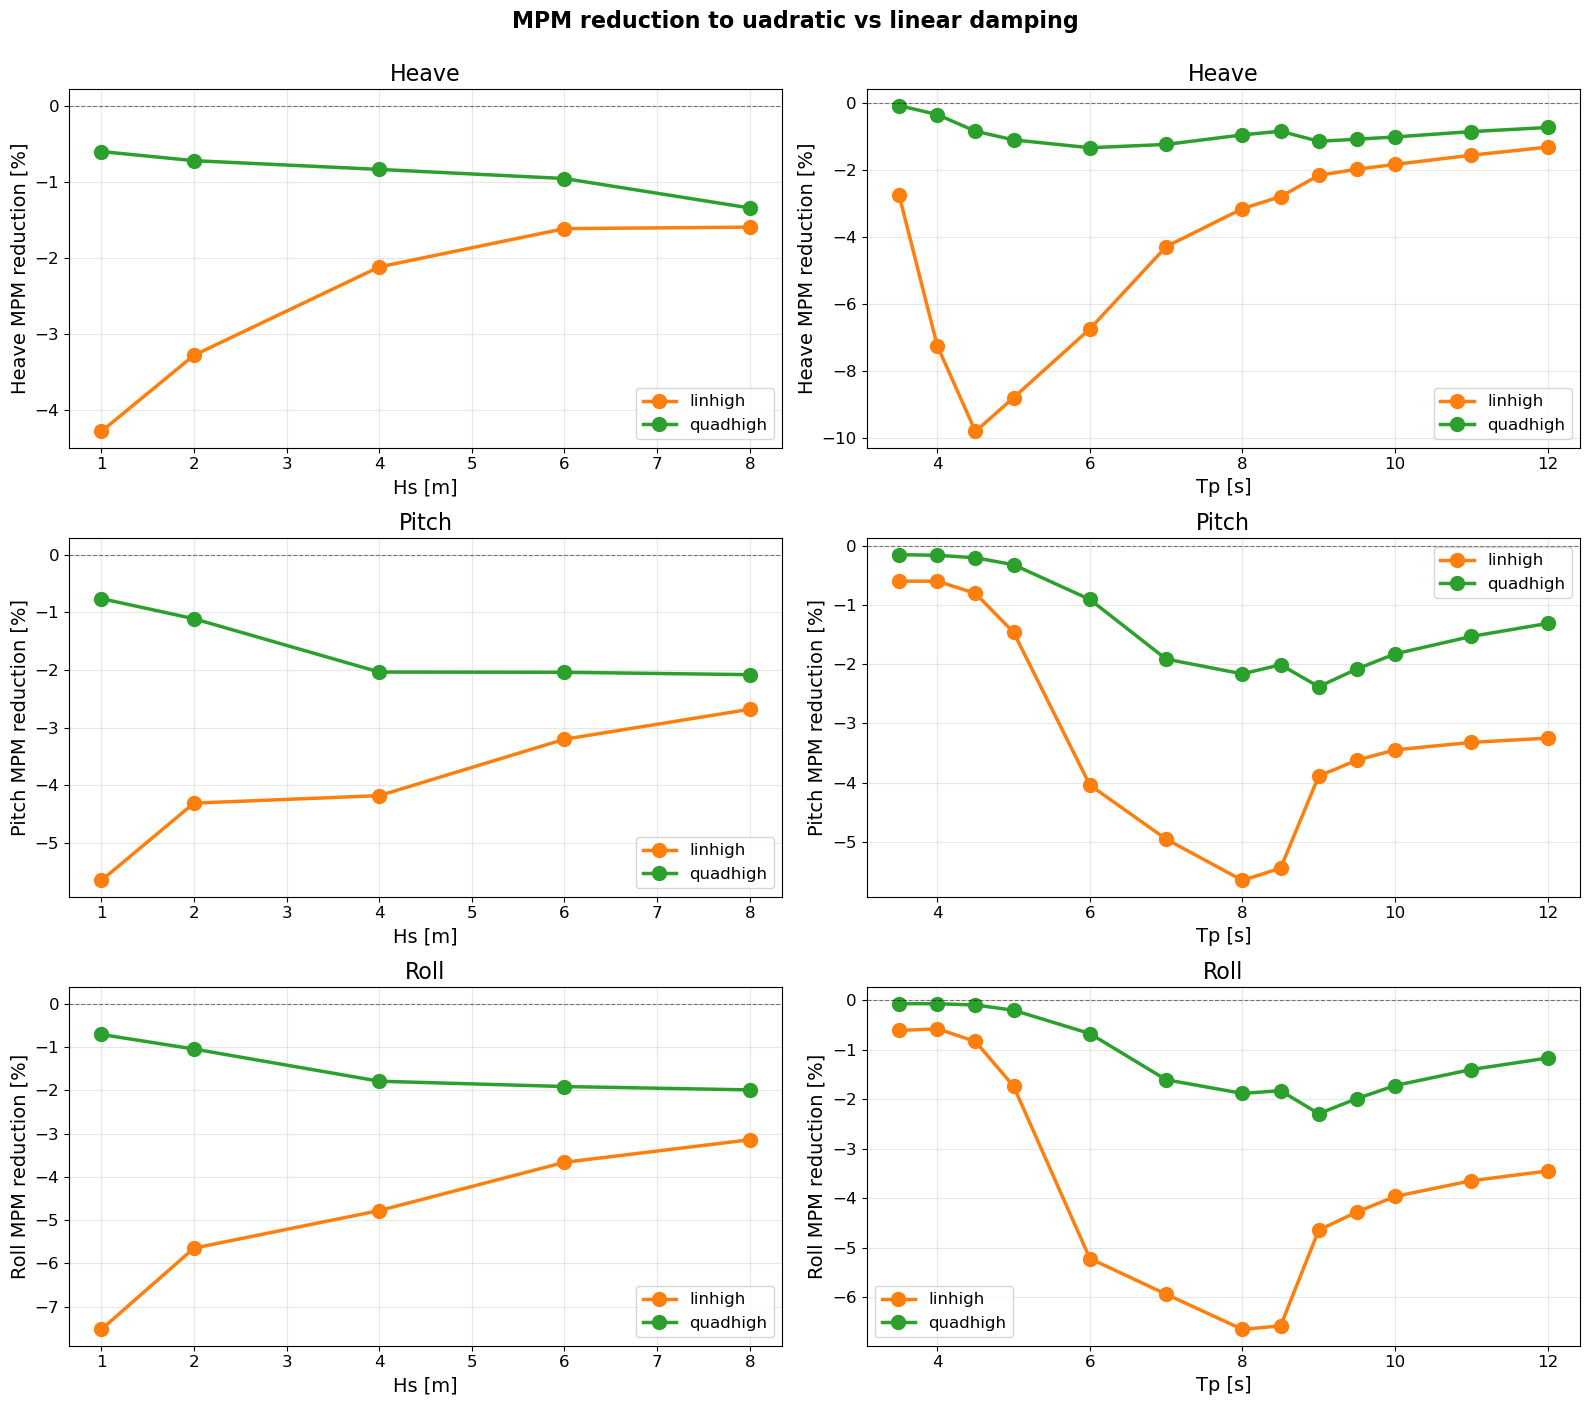

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # vs Hs
    ax = axes[r, 0]
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

    # vs Tp
    ax = axes[r, 1]
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction to uadratic vs linear damping',
             y=1.00, fontweight='bold')
fig.tight_layout()
plt.show()

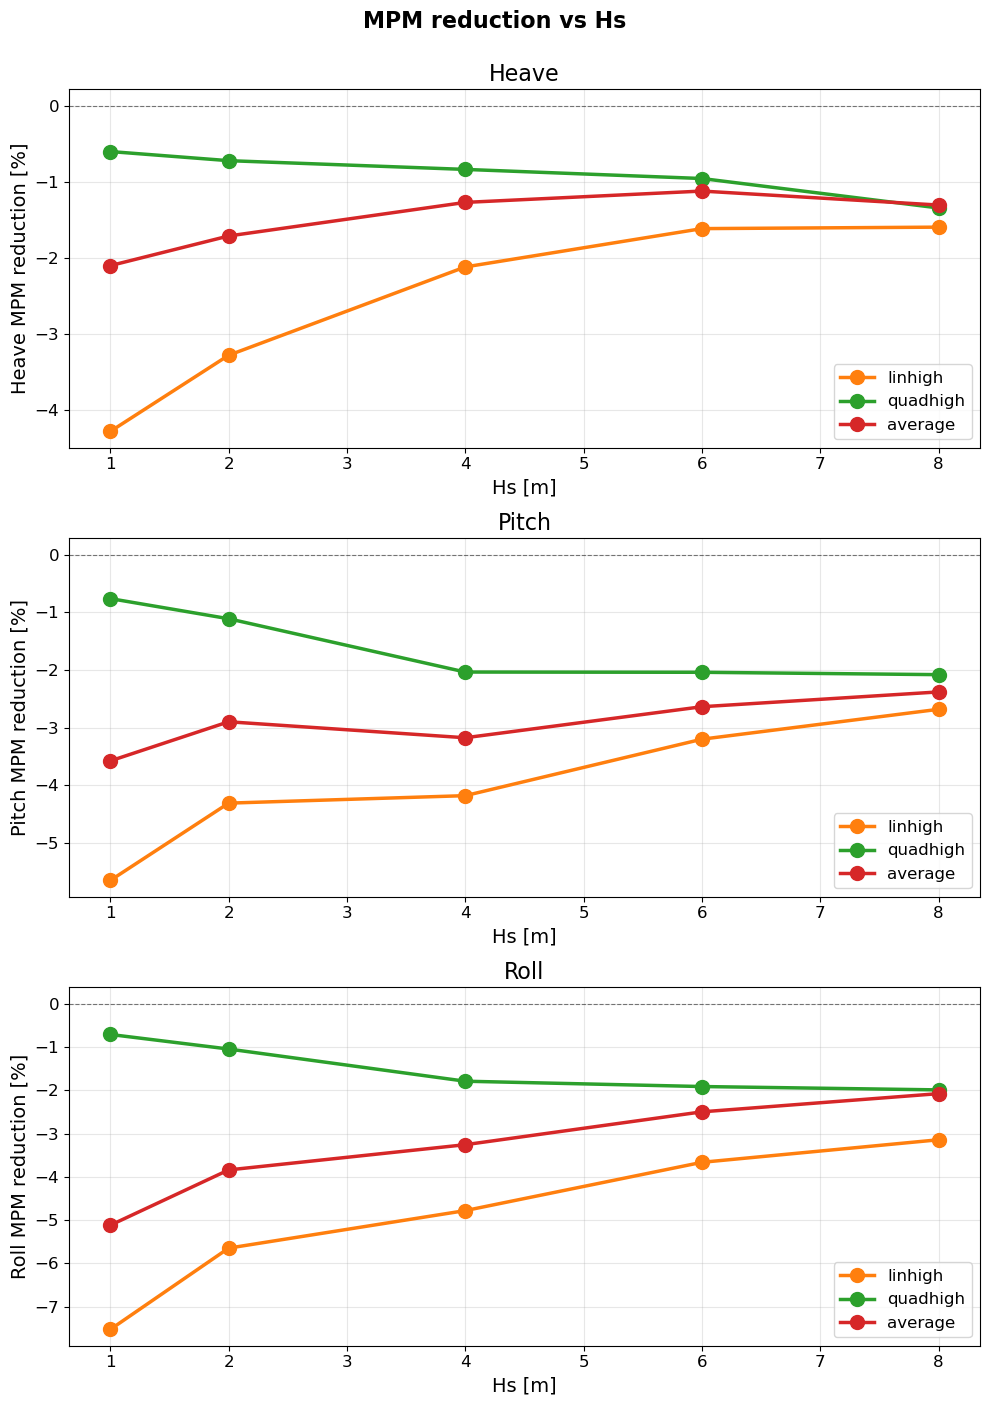

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # vs Hs
    ax = axes[r]
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

#     # vs Tp
#     ax = axes[r, 1]
#     base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()
#     for case in ['linhigh', 'quadhigh']:
#         case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
#         pct = (case_mpm - base) / base * 100
#         ax.plot(pct.index, pct.values, 'o-',
#                 label=case, color=DAMPING_COLORS[case],
#                 linewidth=2.5, markersize=10)
#     ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
#     ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
#     ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
#     ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
#     ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction vs Hs',
             y=1.00, fontweight='bold')
fig.tight_layout()
plt.show()

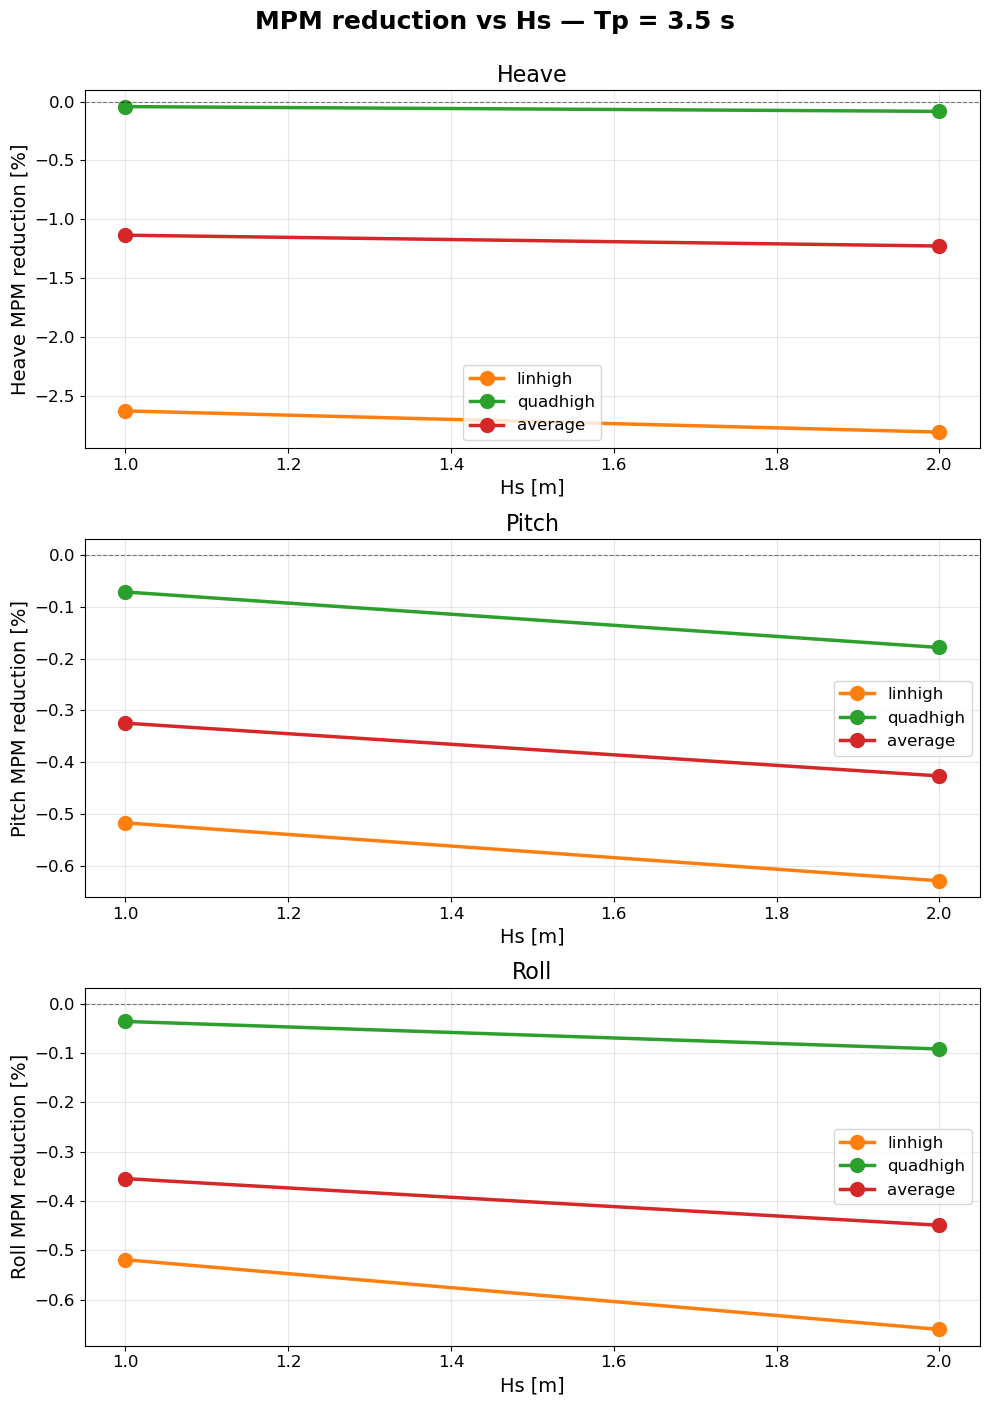

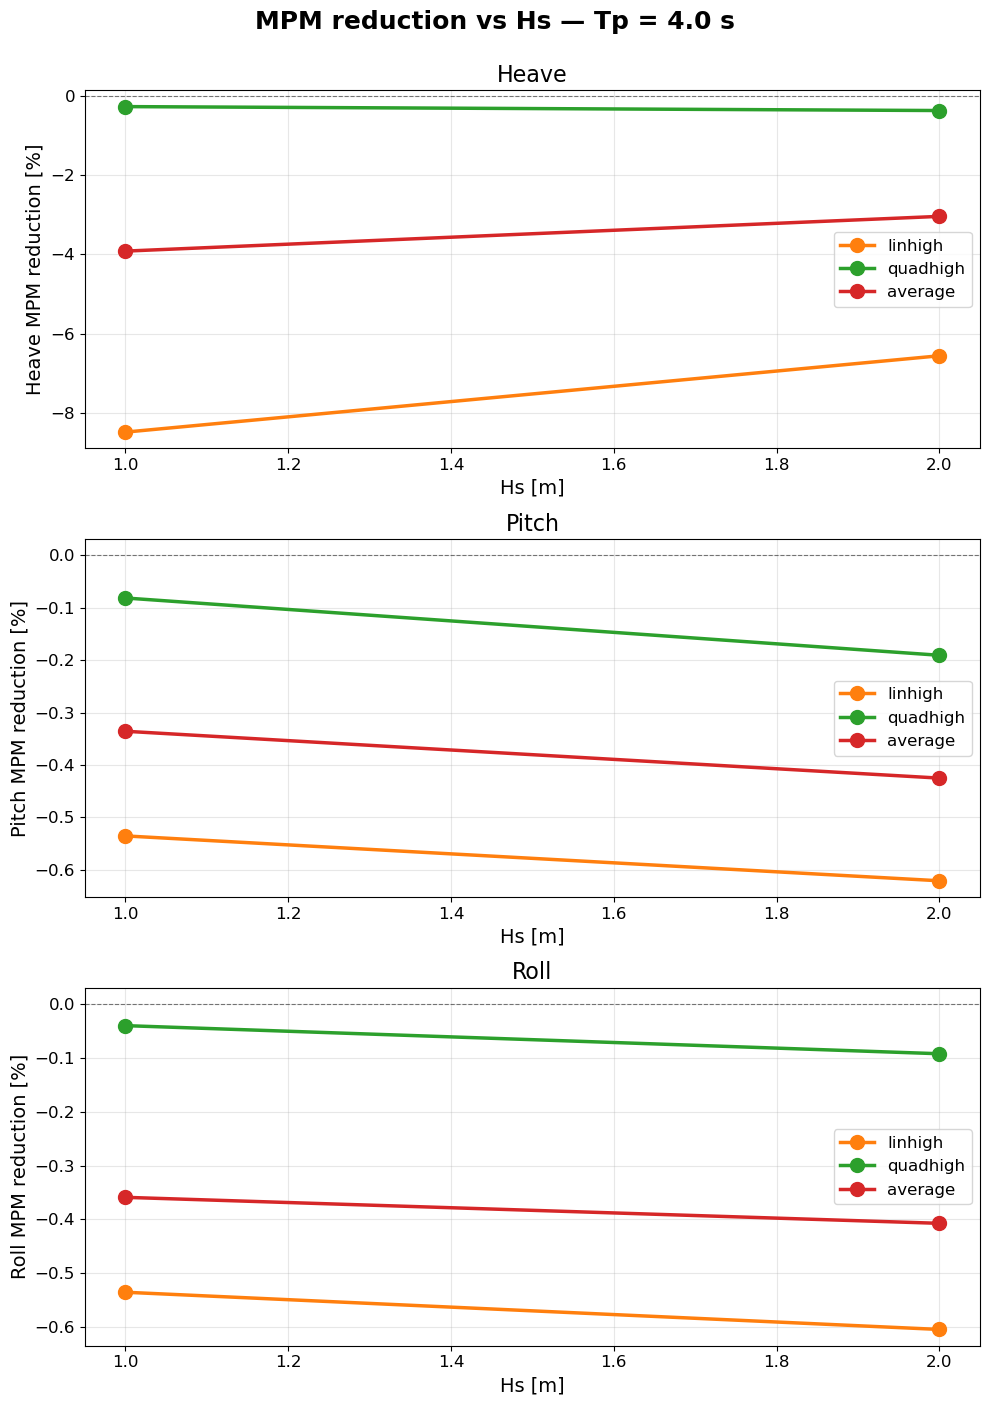

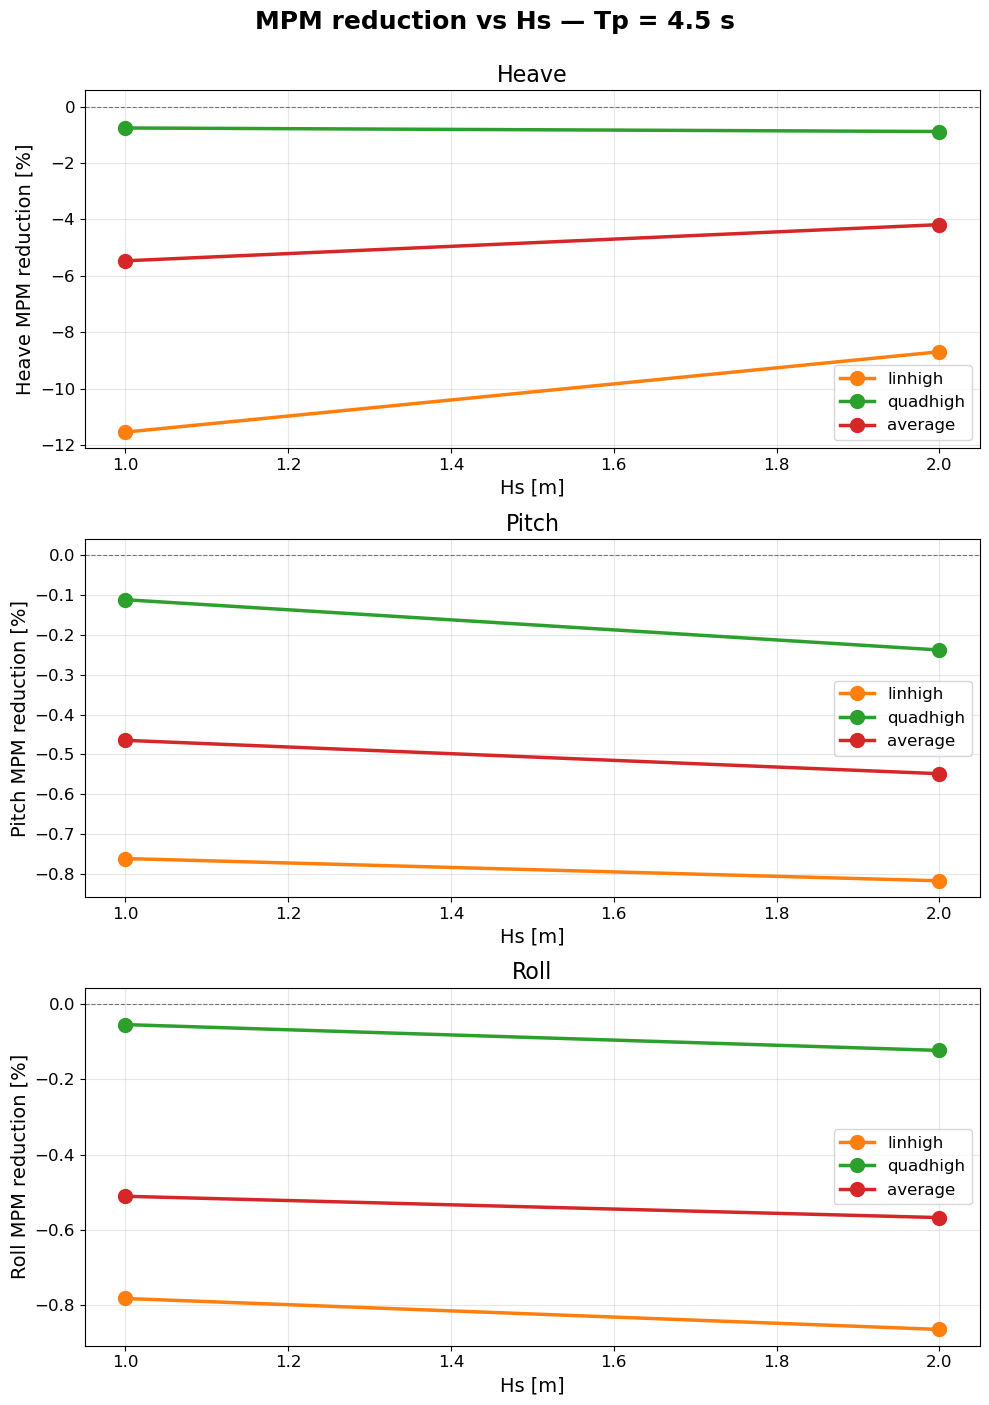

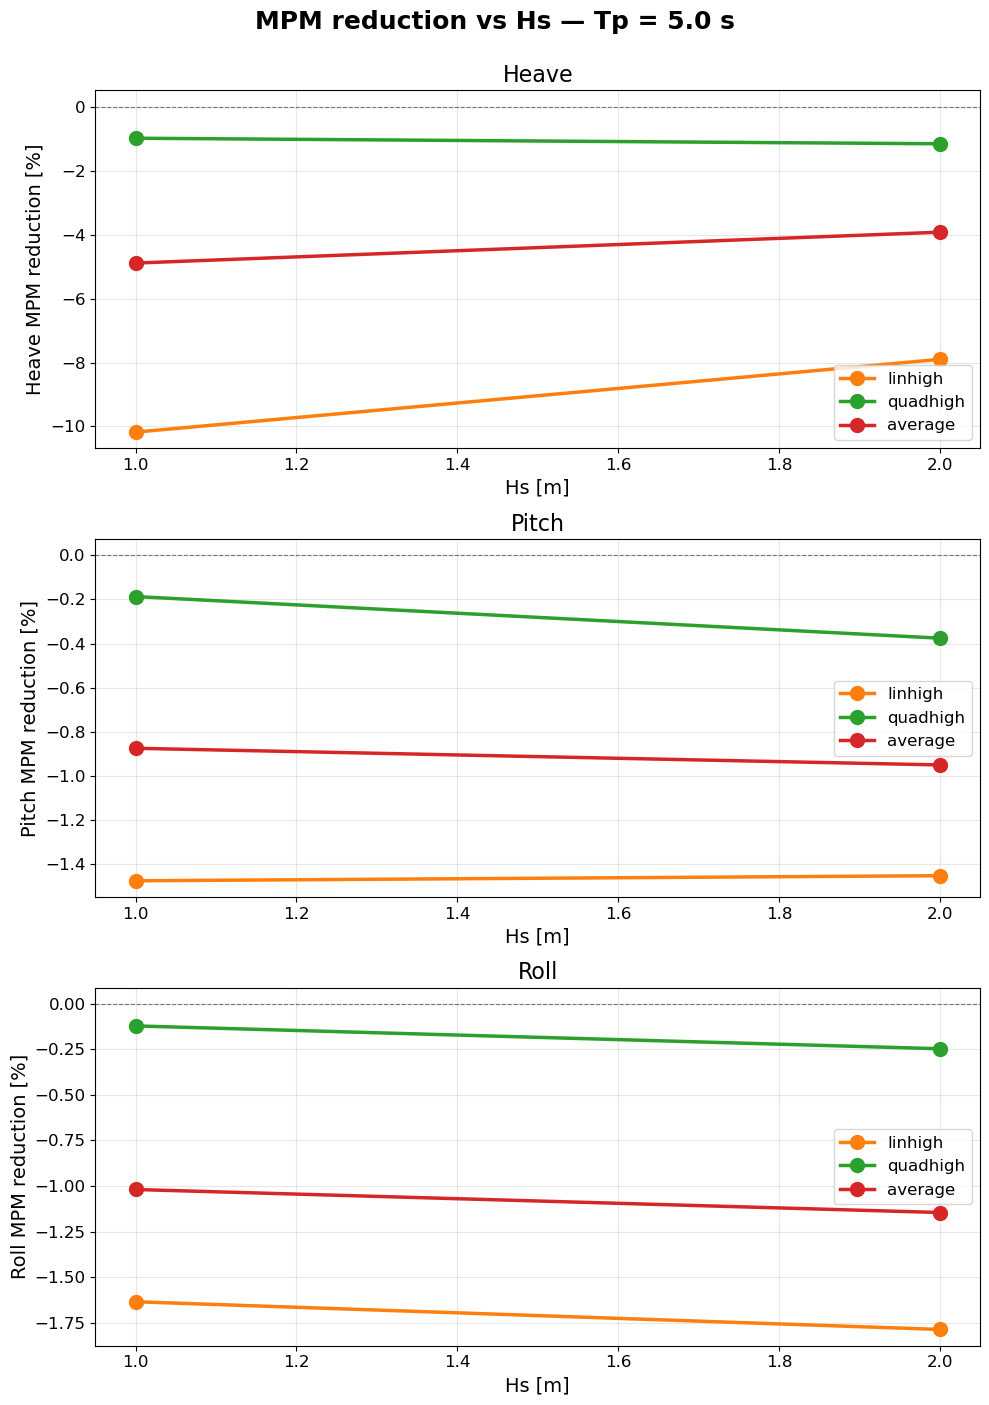

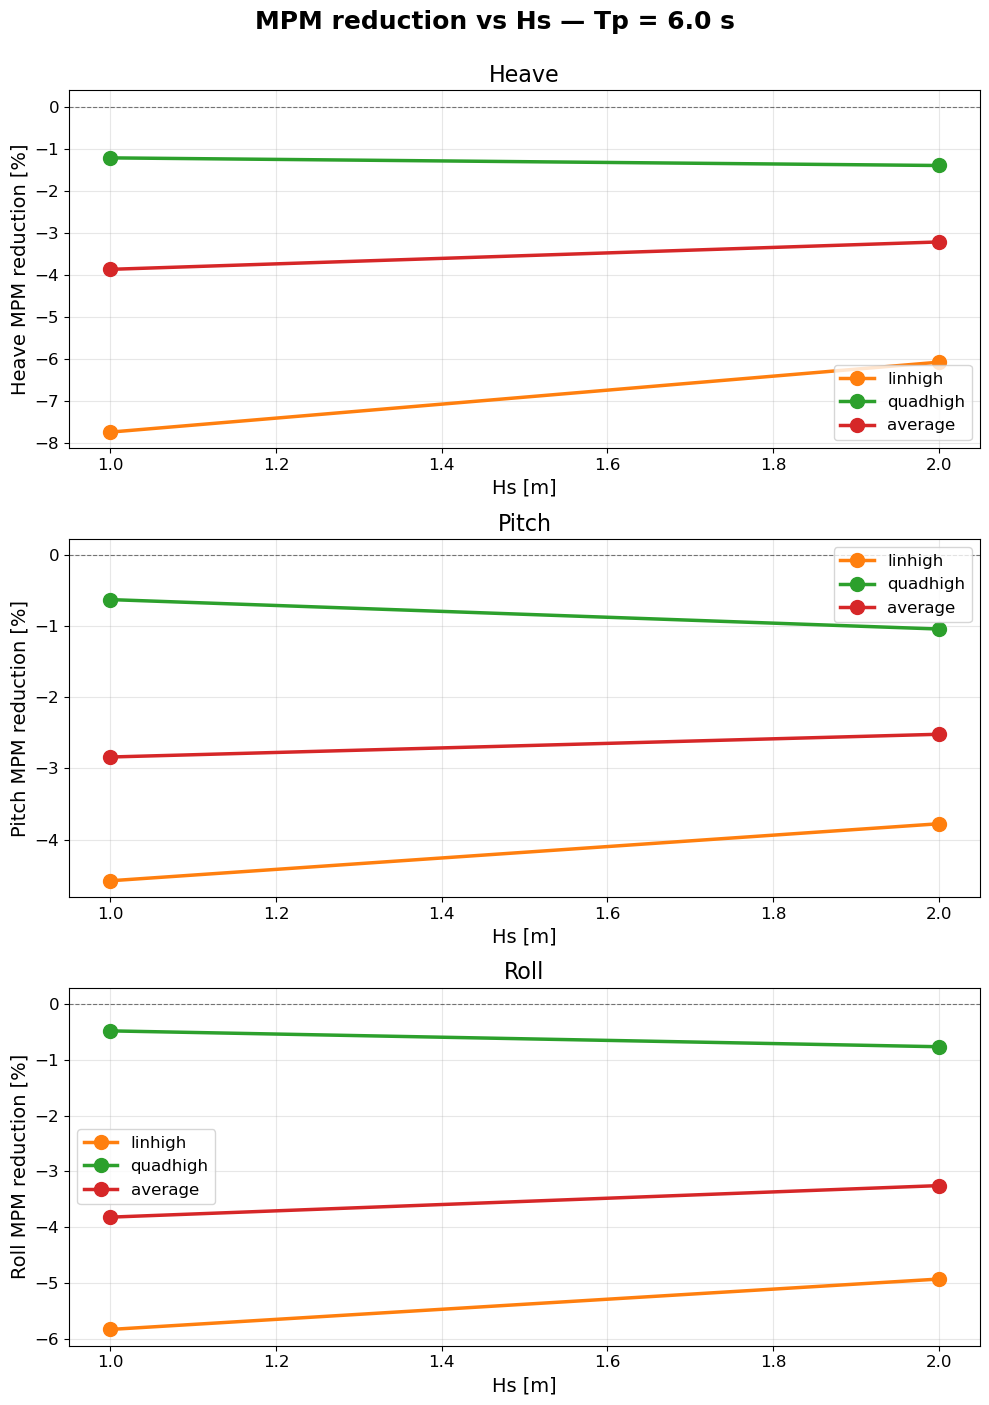

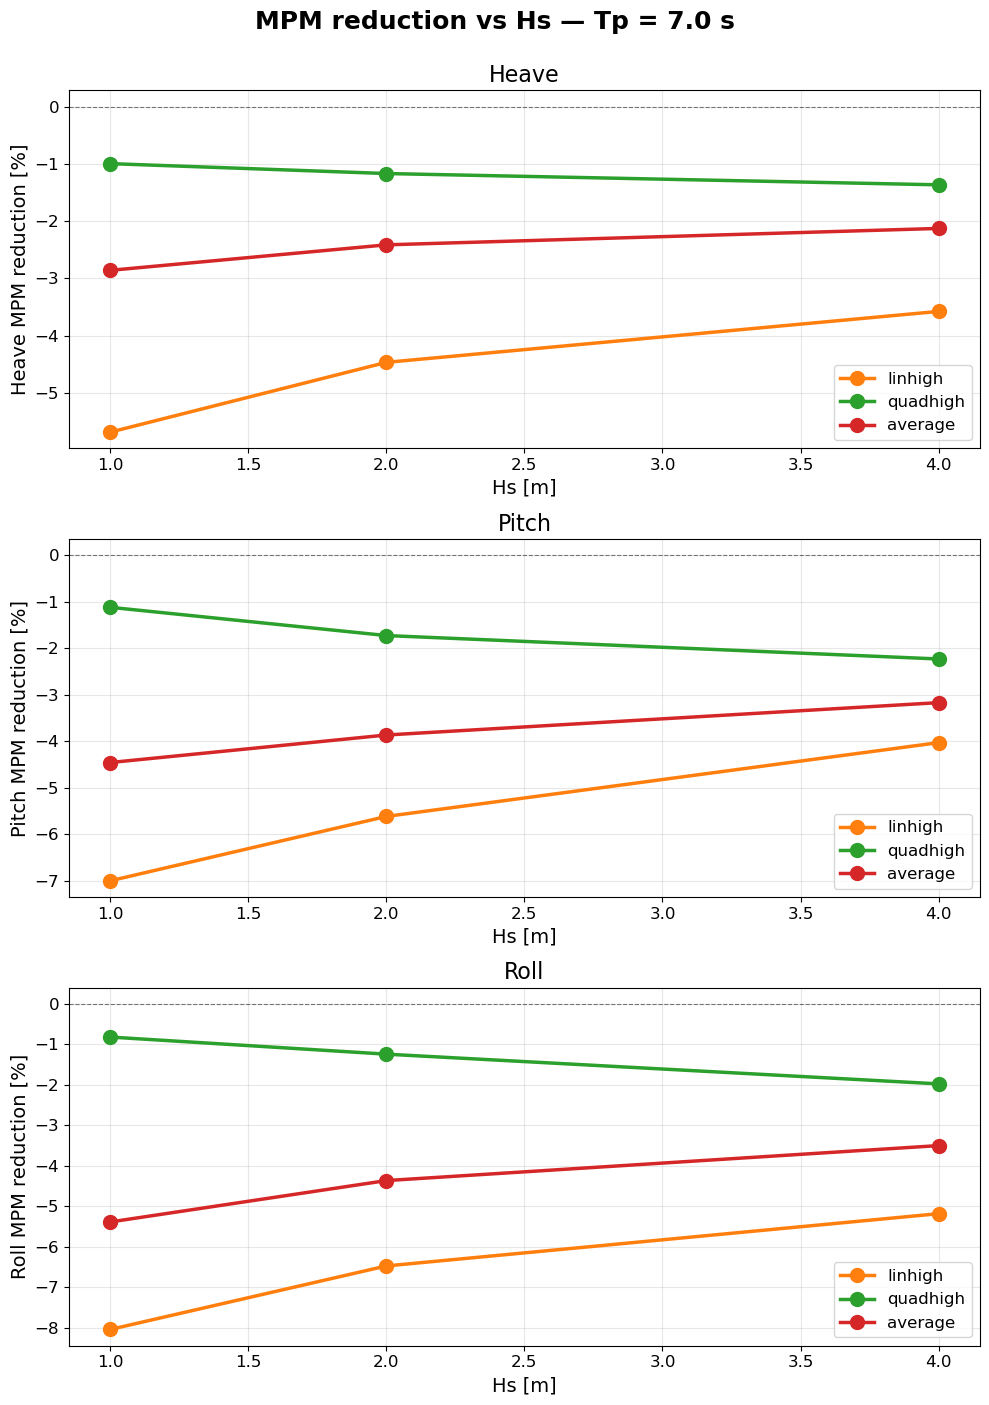

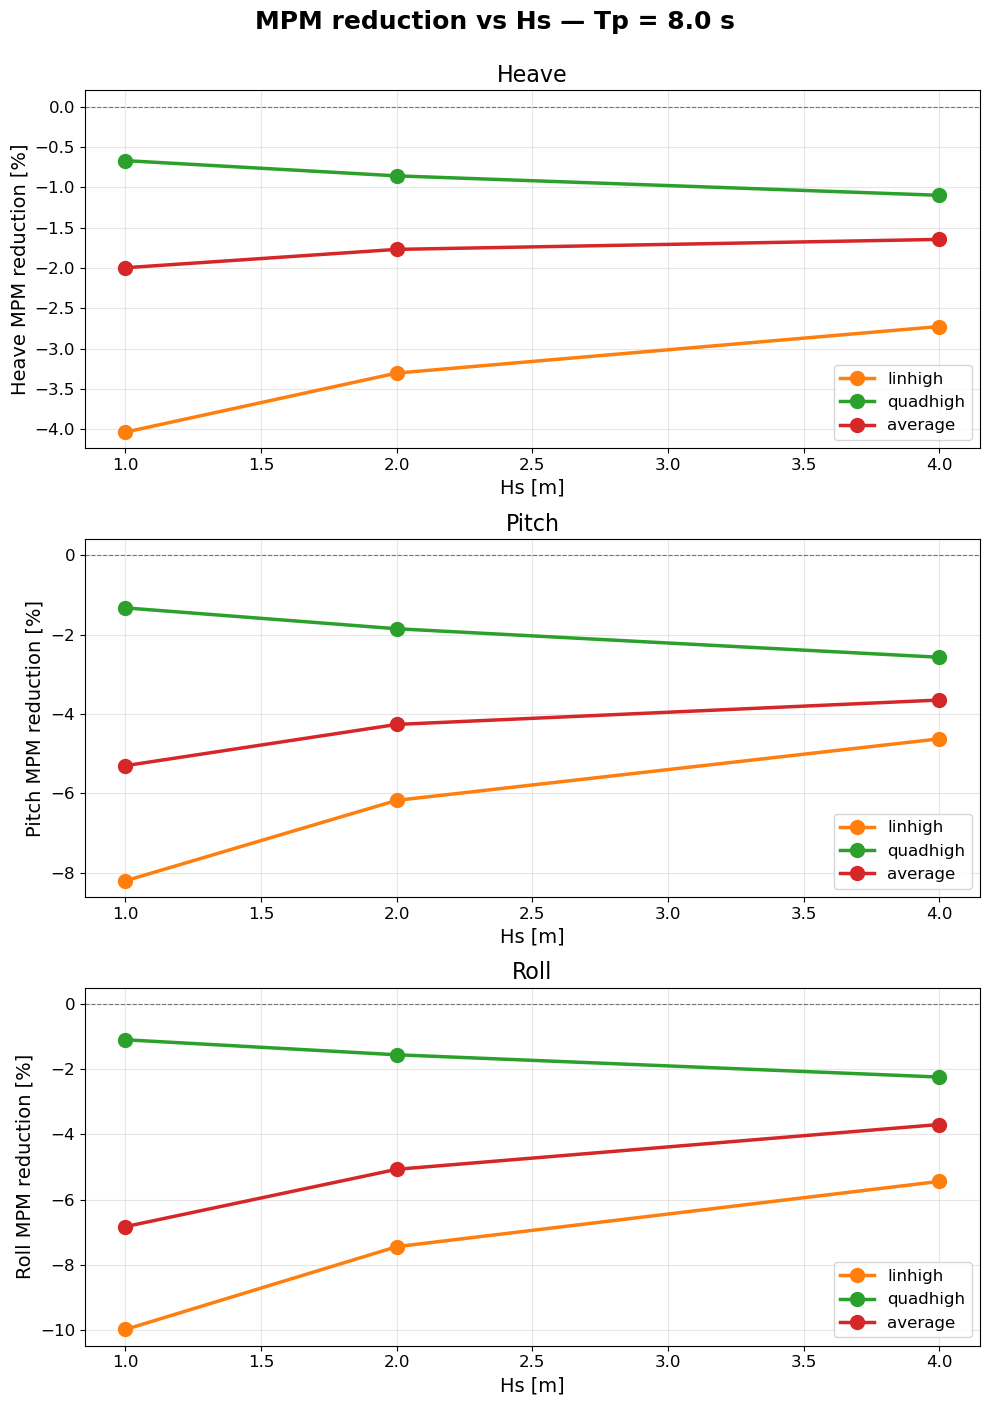

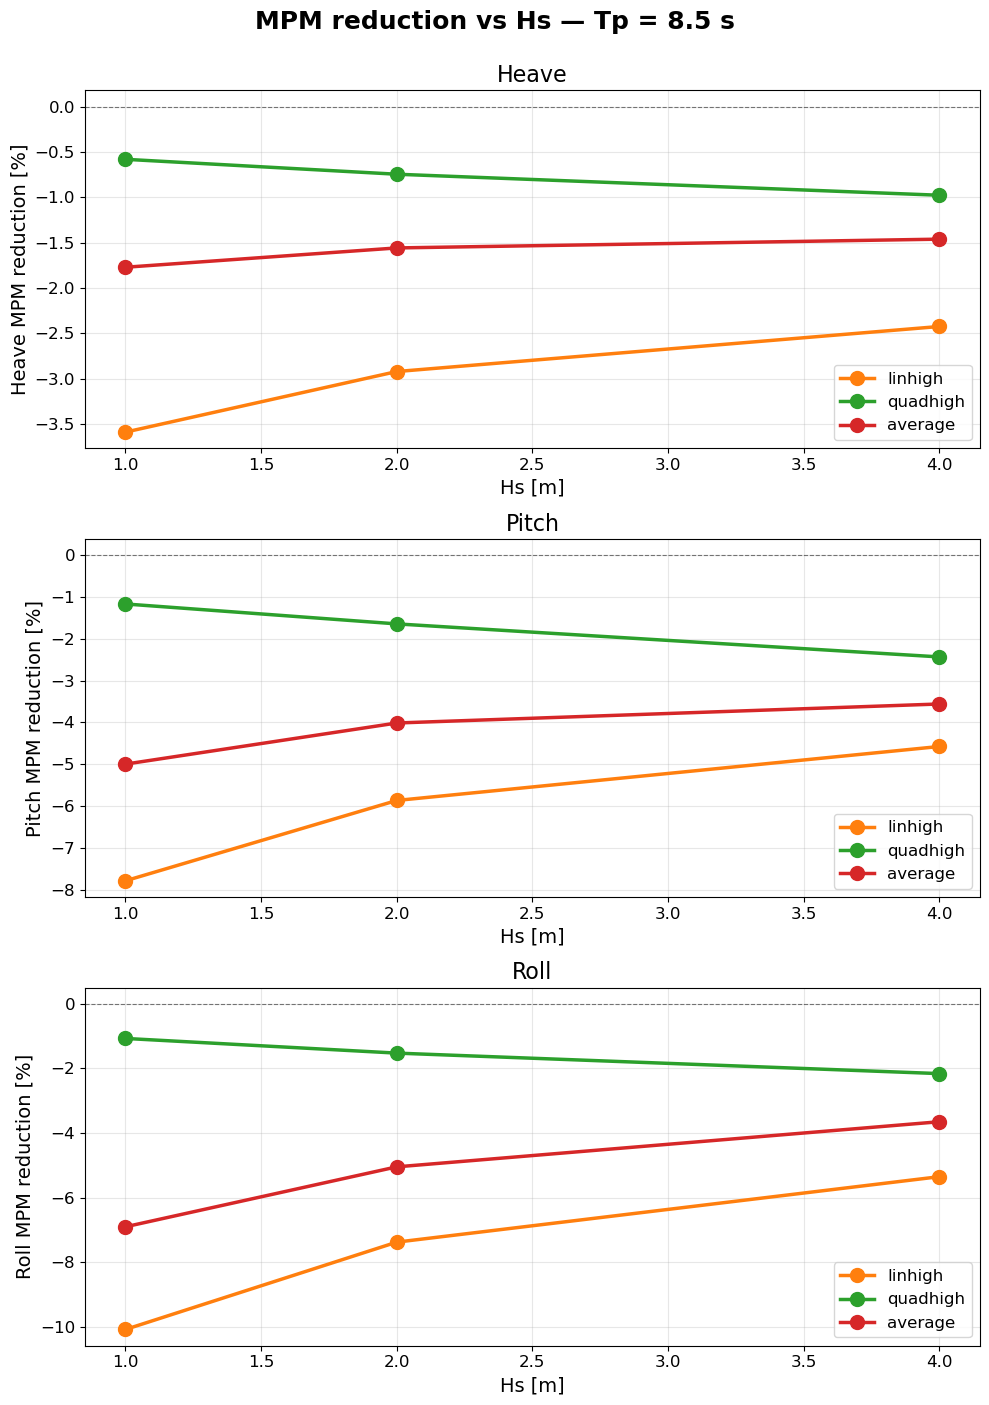

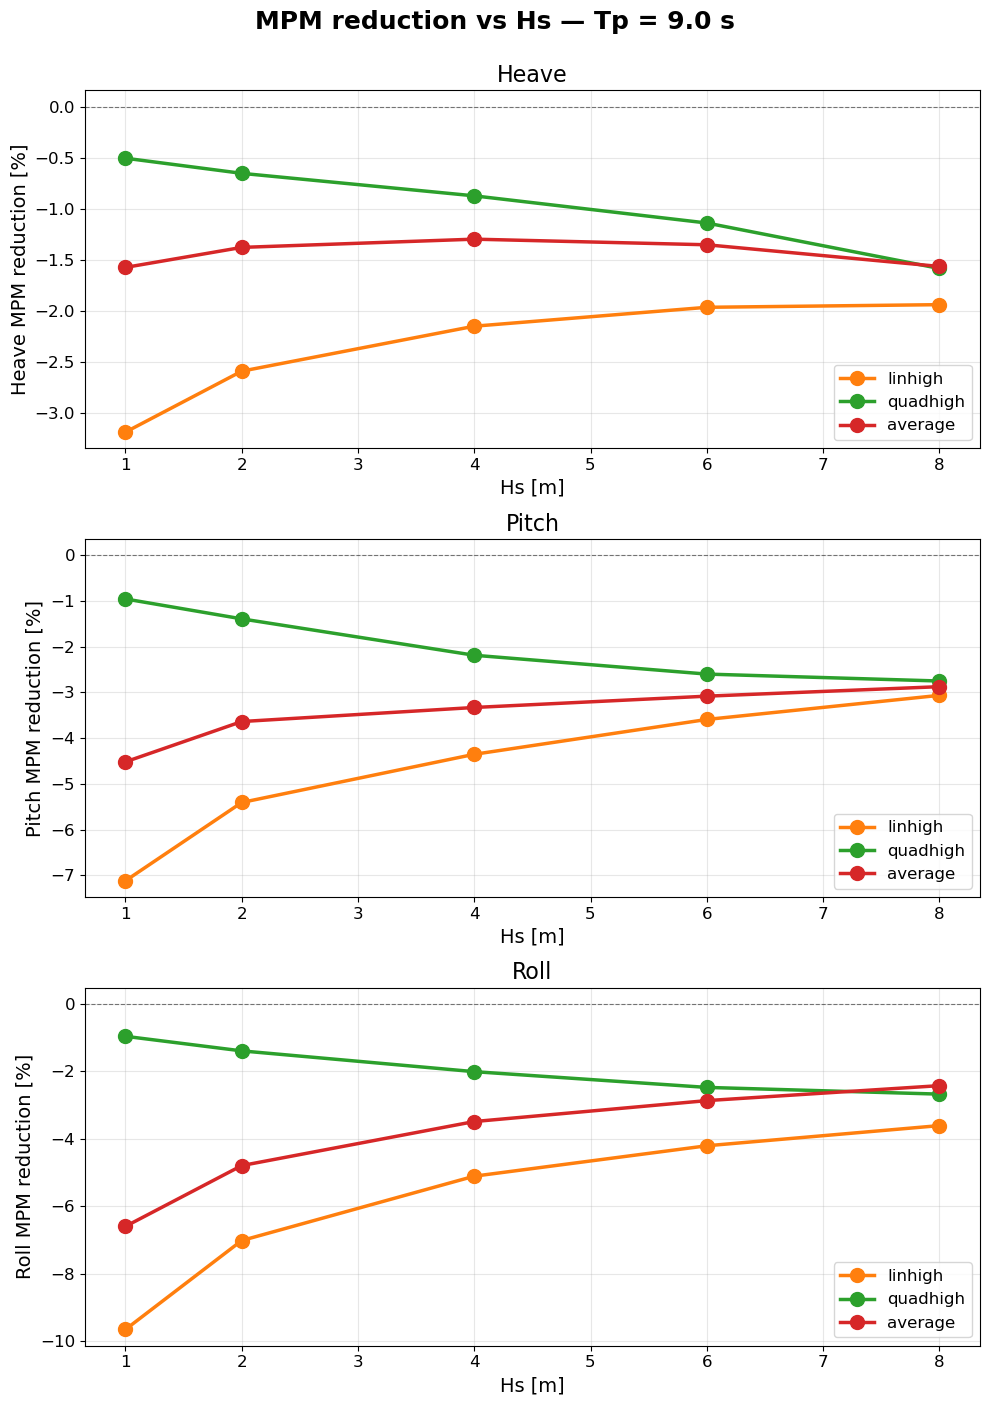

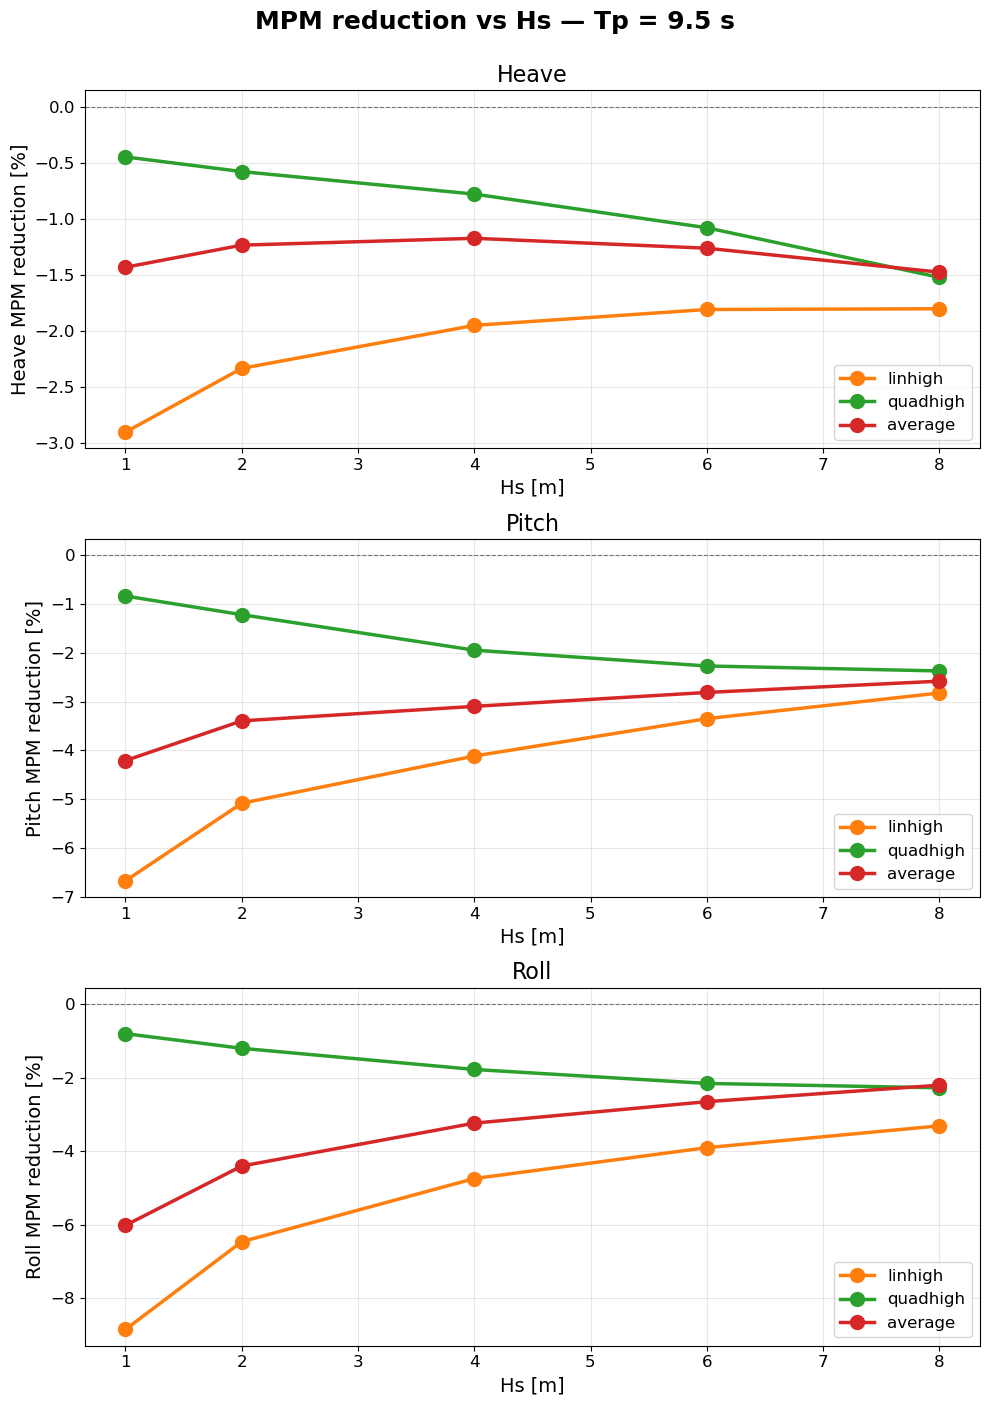

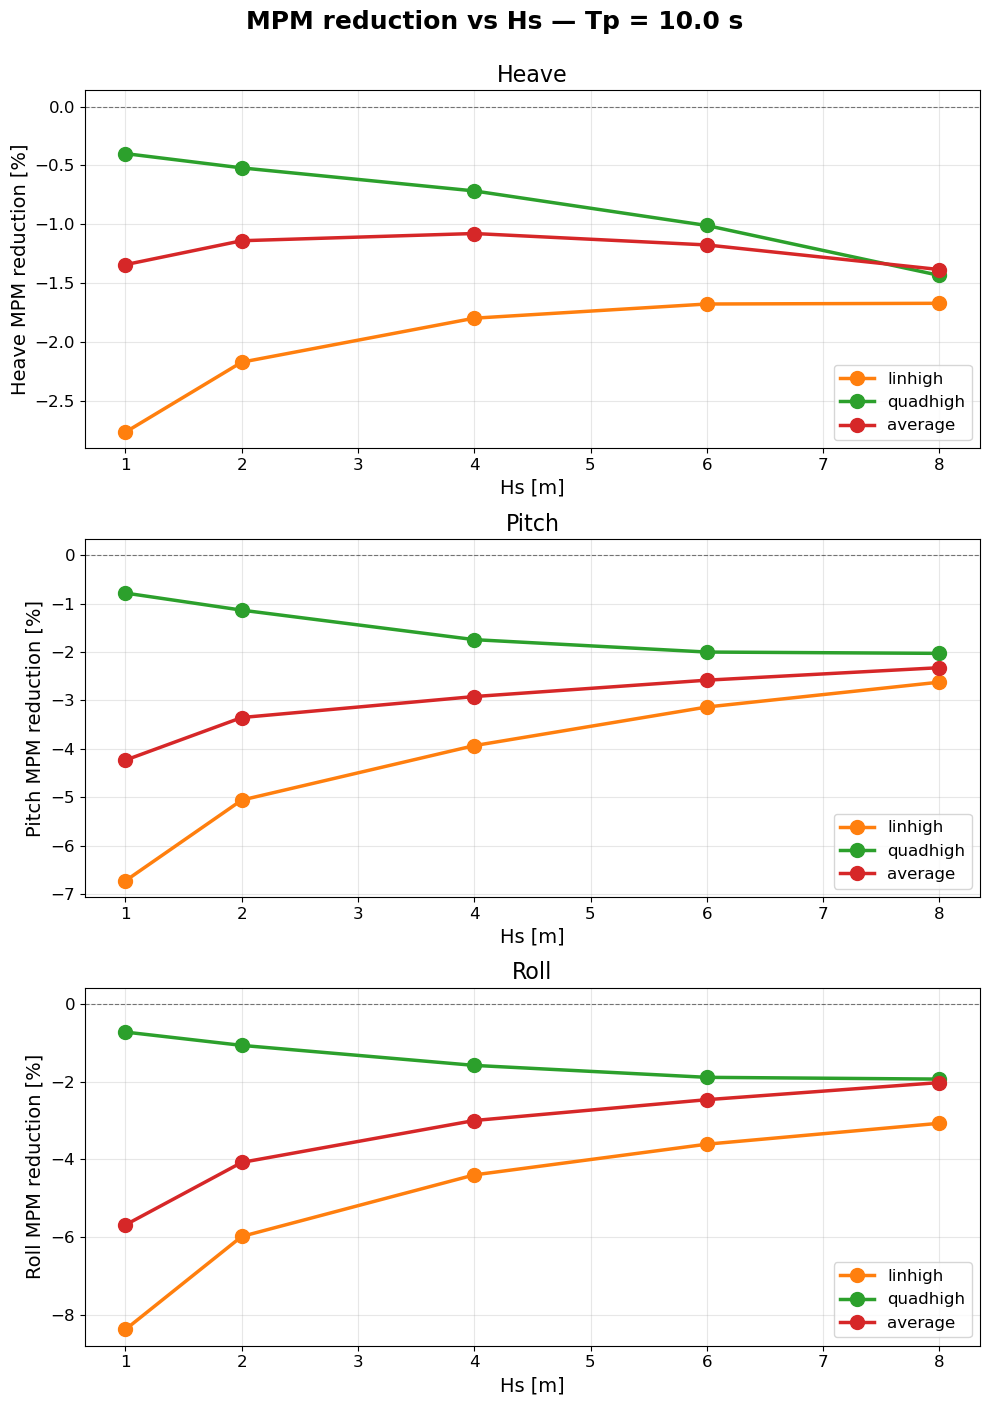

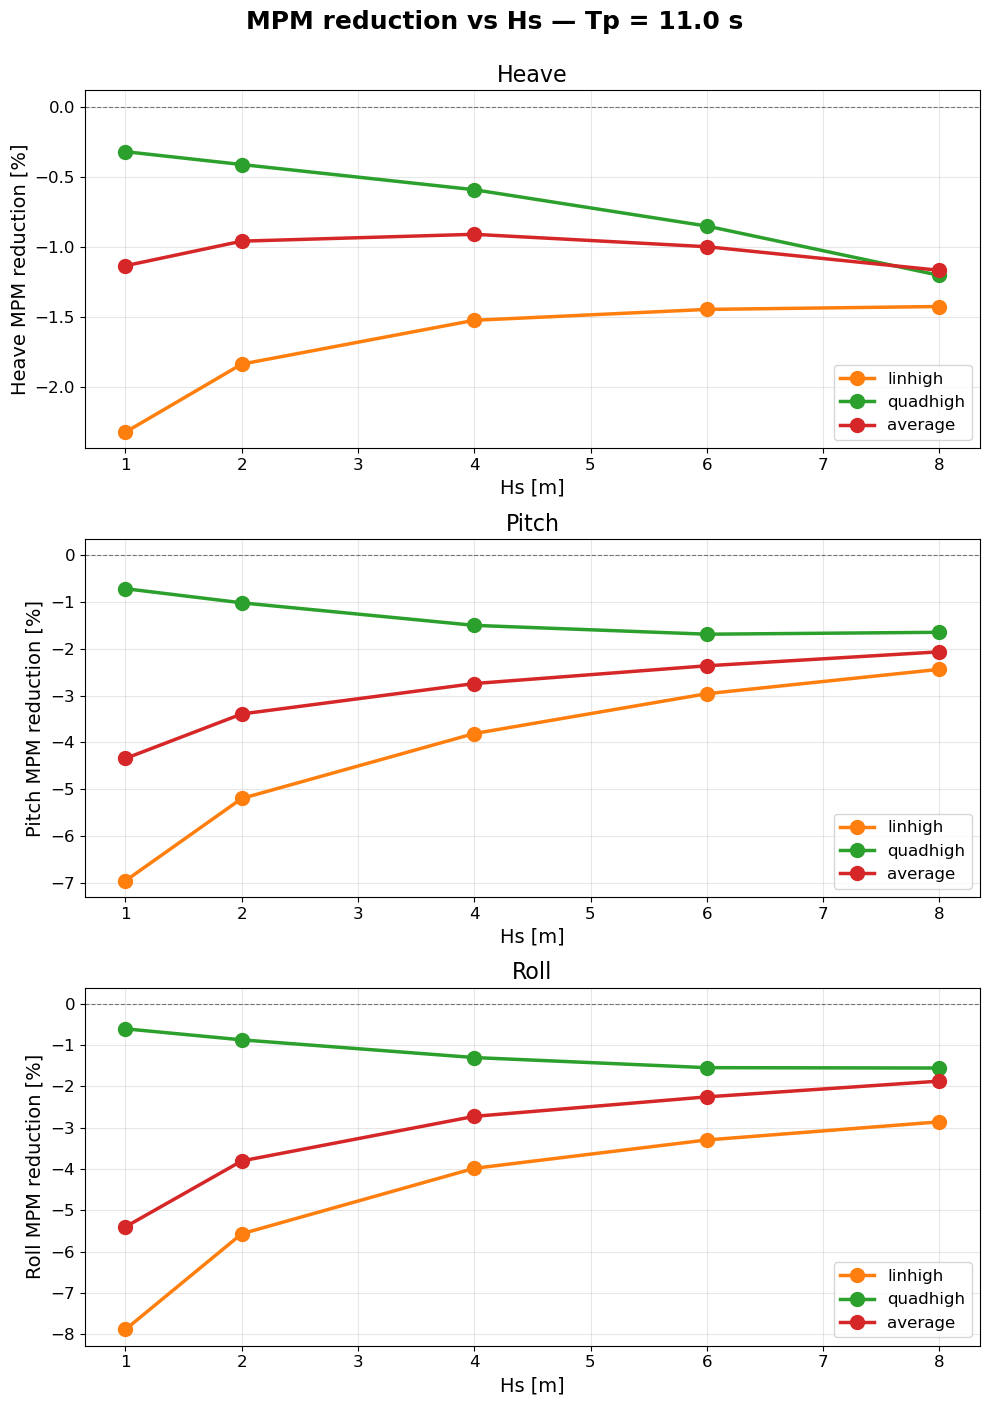

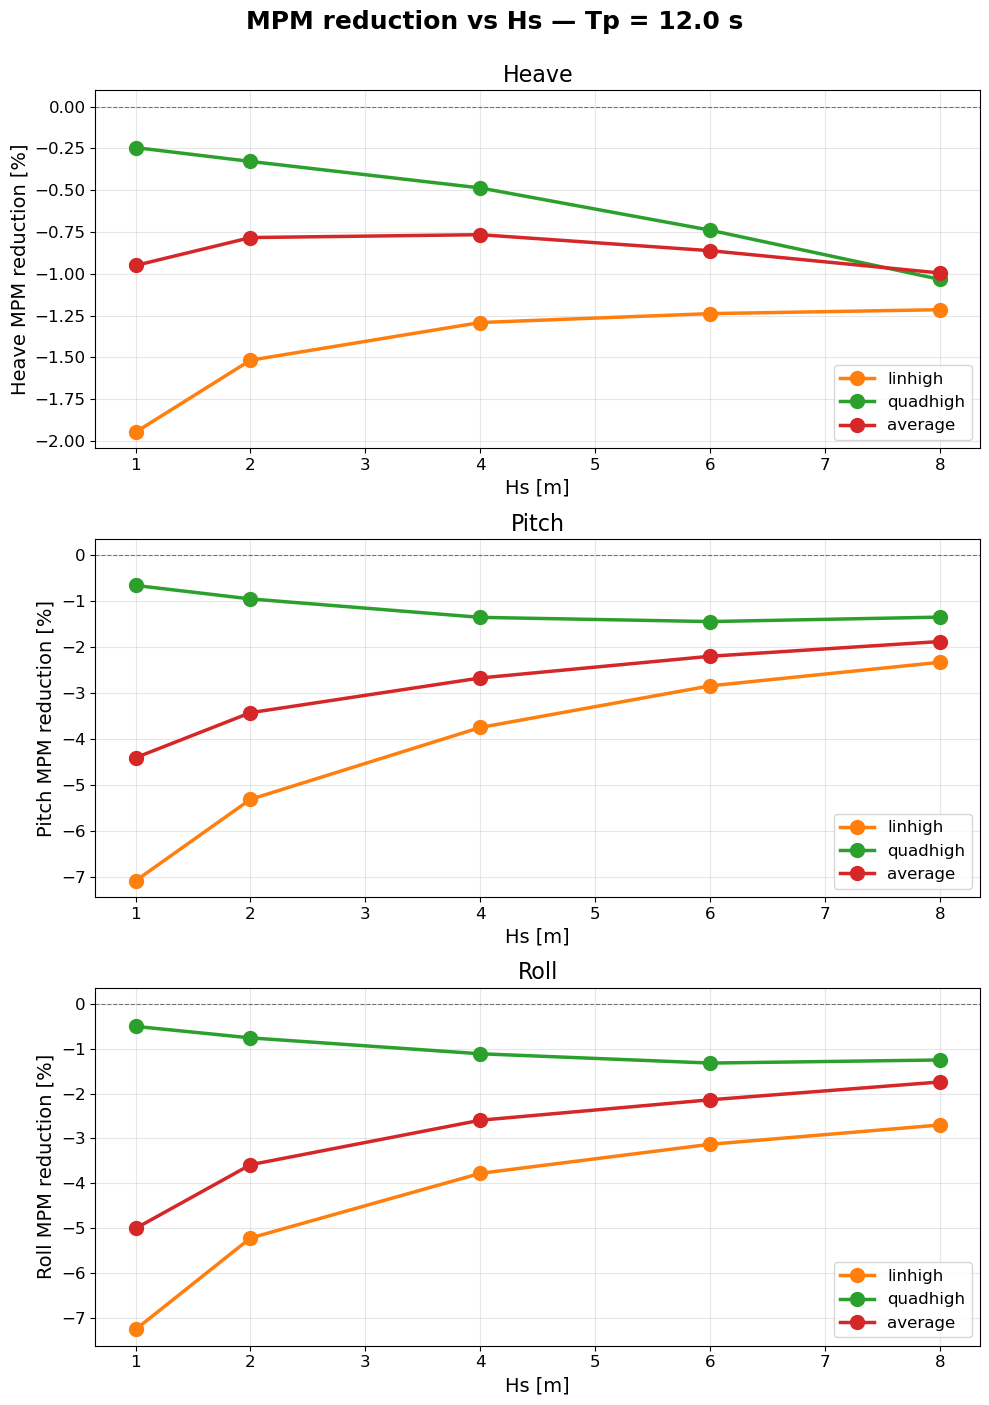

In [10]:
TP_VALUES = sorted(df['Tp'].unique())

for tp in TP_VALUES:
    sub_tp = df[df['Tp'] == tp]
    fig, axes = plt.subplots(3, 1, figsize=(10, 14))

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_tp, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        ax = axes[r]
        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
        for case in ['linhigh', 'quadhigh', 'average']:
            case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
            common = case_mpm.index.intersection(base.index)
            if len(common) == 0:
                continue
            pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
            ax.plot(common, pct.values, 'o-',
                    label=case, color=DAMPING_COLORS[case],
                    linewidth=2.5, markersize=10)
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
        ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
        ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=TICK_SIZE)

    fig.suptitle(f'MPM reduction vs Hs — Tp = {tp} s',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()

plt.show()

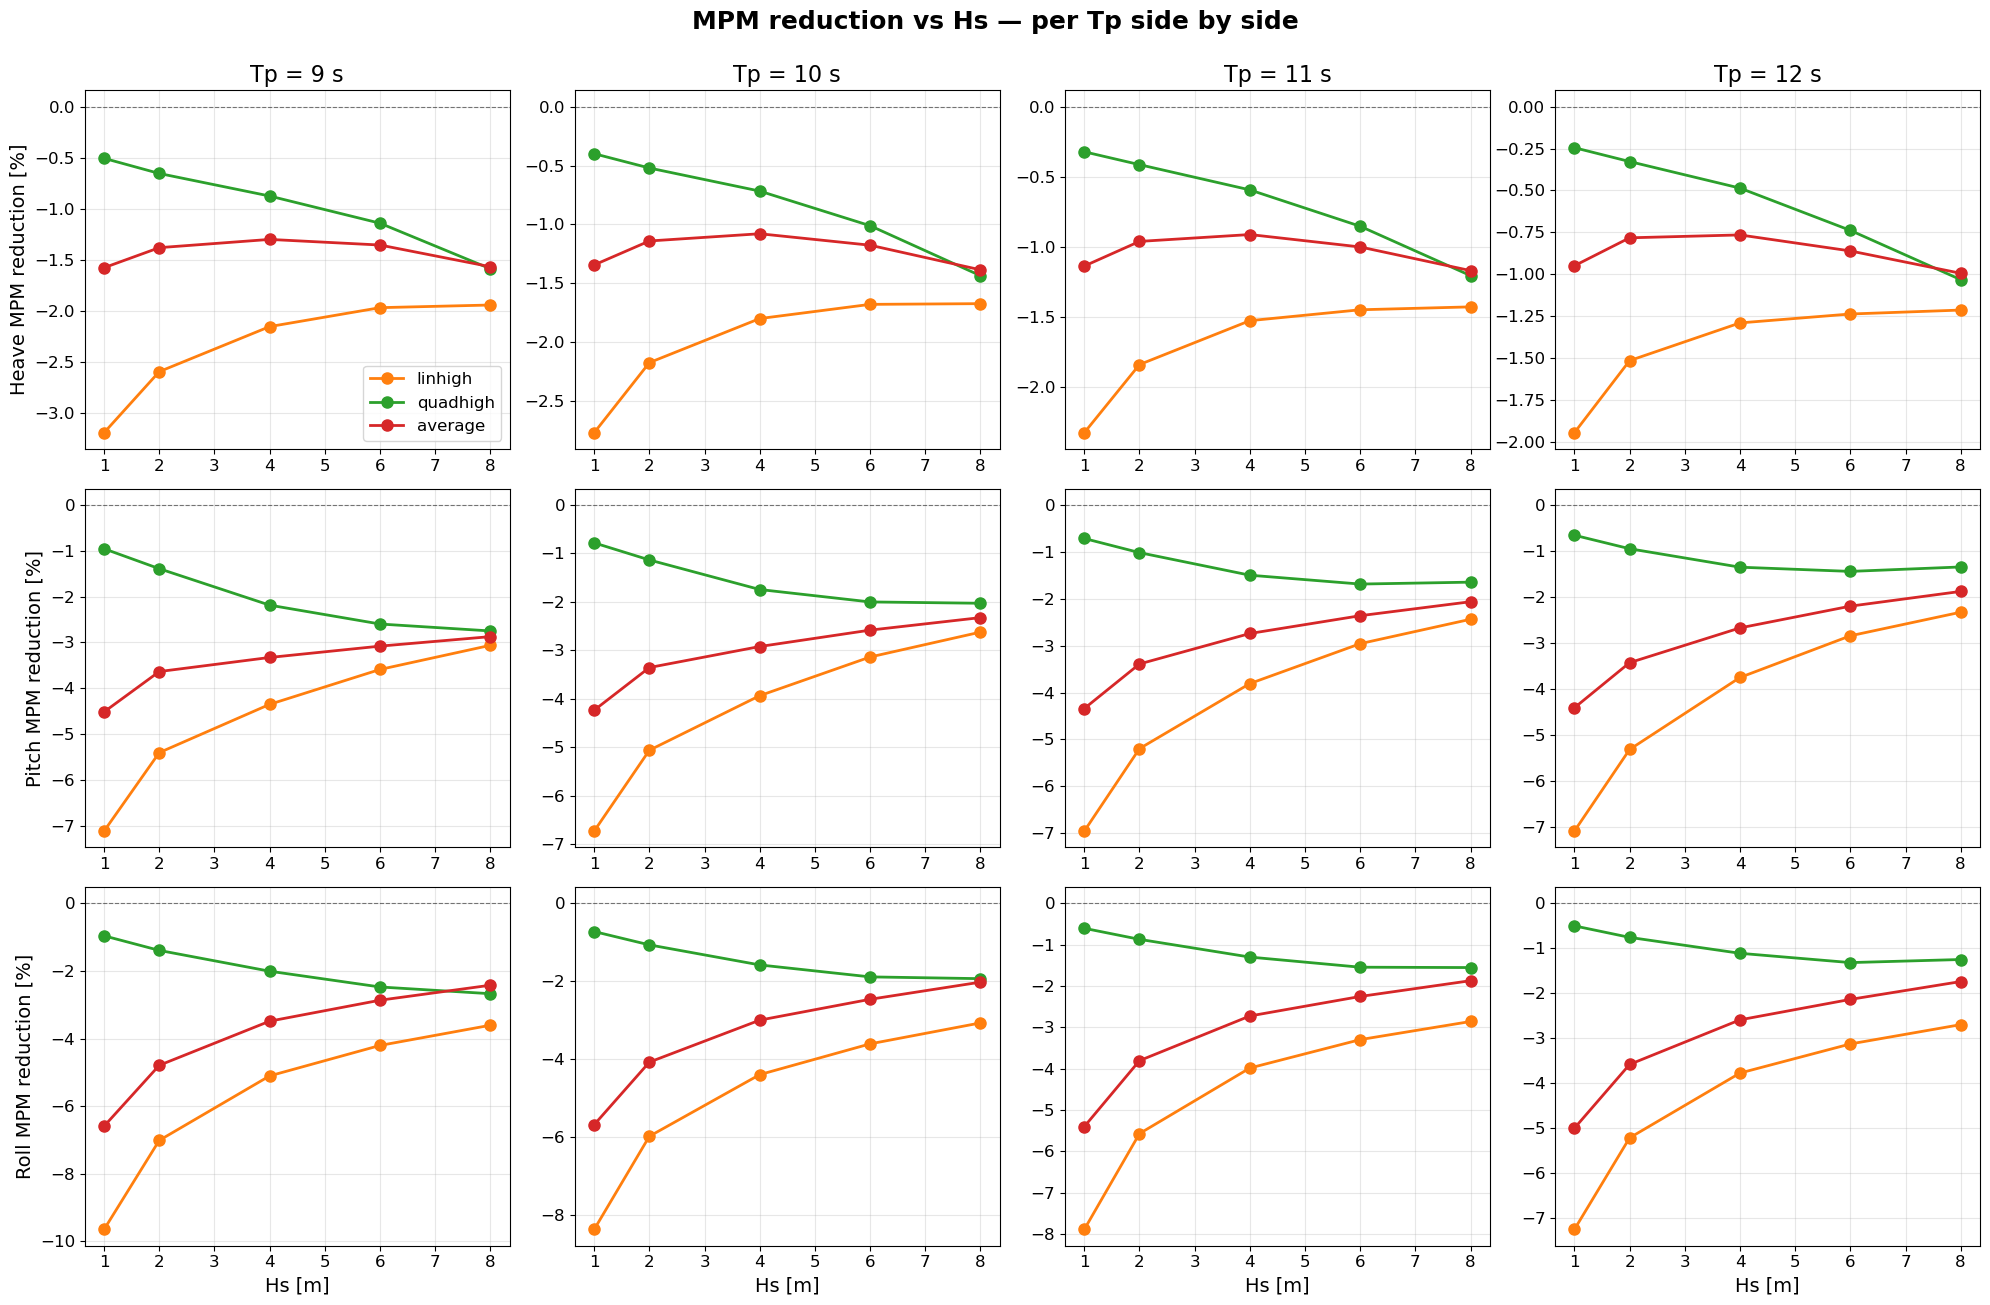

In [14]:
# Combined overview: MPM reduction vs Hs for a selection of Tp values side by side
TP_SELECTION = [9,10,11,12]

fig, axes = plt.subplots(3, len(TP_SELECTION), figsize=(5*len(TP_SELECTION), 13),
                         squeeze=False)

for c, tp in enumerate(TP_SELECTION):
    sub_tp = df[df['Tp'] == tp]
    for r, dof in enumerate(DOFS):
        ax = axes[r, c]
        sub_dof = filter_dirs(sub_tp, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
        for case in ['linhigh', 'quadhigh', 'average']:
            case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
            common = case_mpm.index.intersection(base.index)
            if len(common) == 0:
                continue
            pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
            ax.plot(common, pct.values, 'o-',
                    label=case, color=DAMPING_COLORS[case],
                    linewidth=2, markersize=8)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if r == 0:
            ax.set_title(f'Tp = {tp} s', fontsize=TITLE_SIZE)
        if r == 0 and c == 0:
            ax.legend(fontsize=TICK_SIZE)
        if r == 2:
            ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)

fig.suptitle('MPM reduction vs Hs — per Tp side by side',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

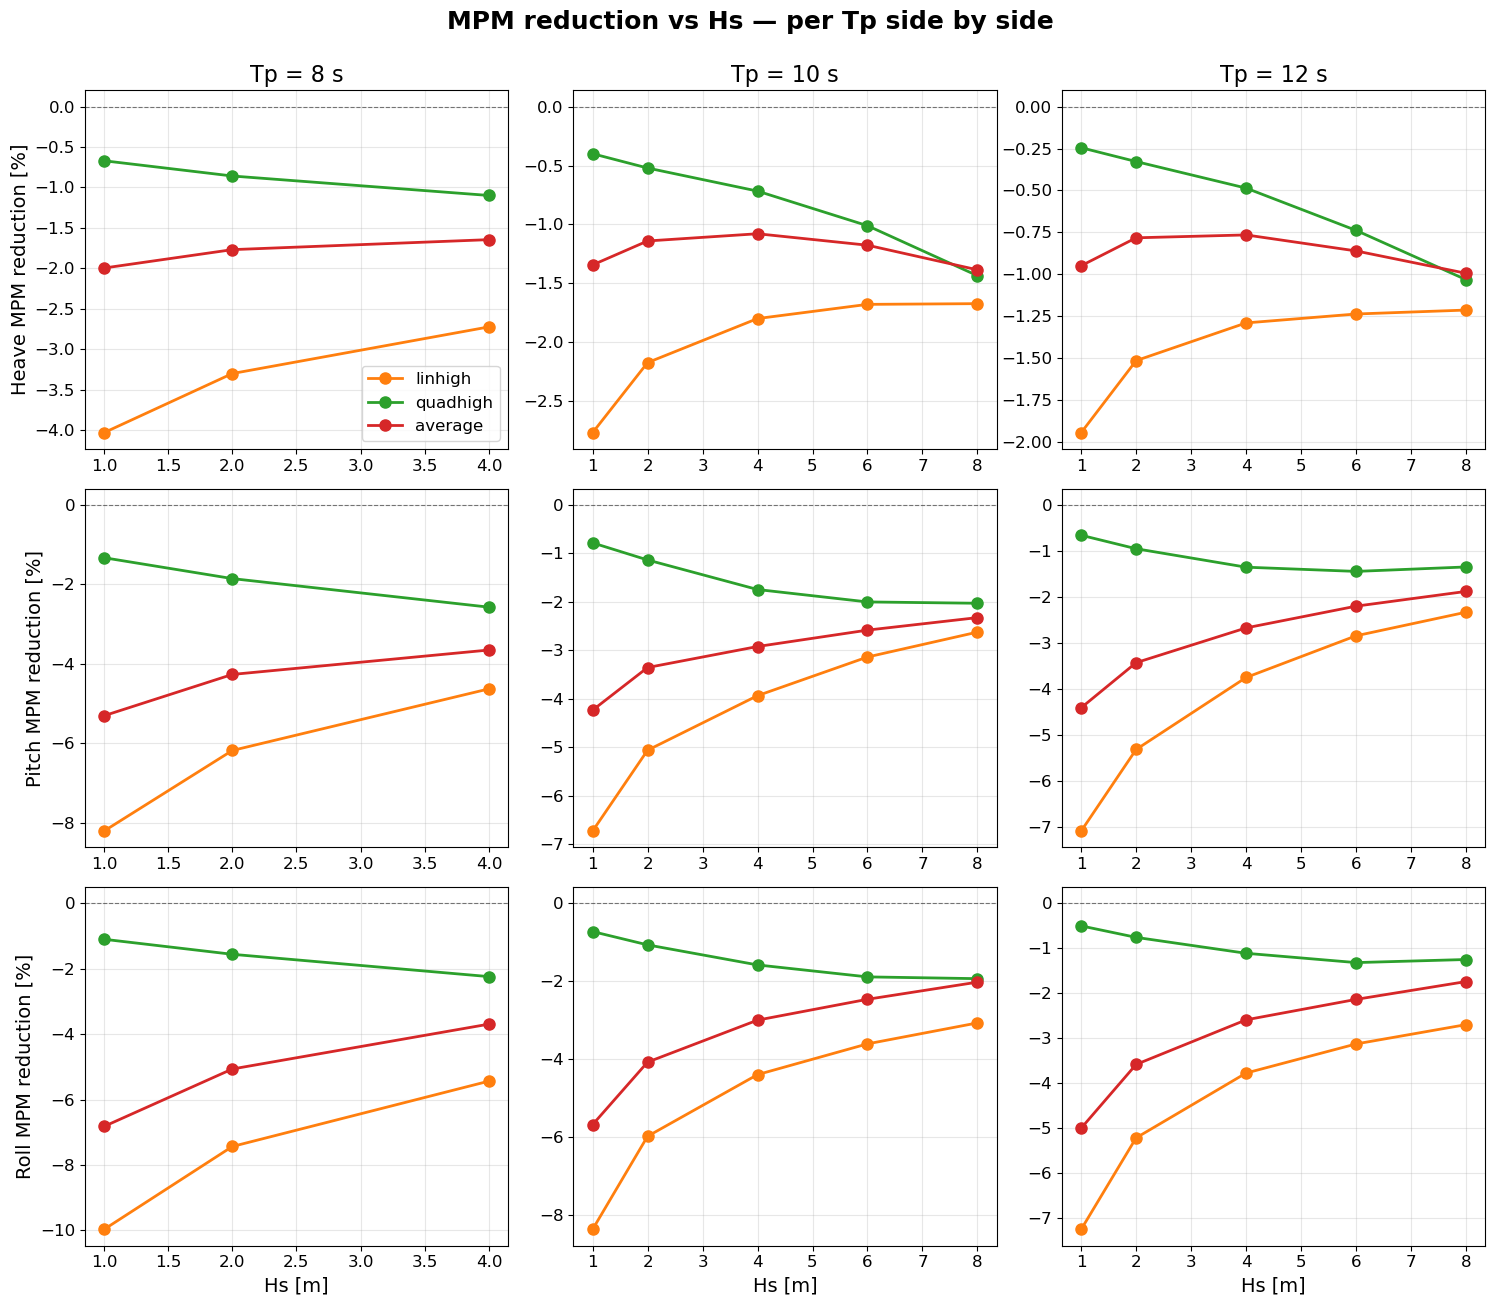

In [13]:
# Combined overview: MPM reduction vs Hs for a selection of Tp values side by side
TP_SELECTION = [ 8, 10, 12]

fig, axes = plt.subplots(3, len(TP_SELECTION), figsize=(5*len(TP_SELECTION), 13),
                         squeeze=False)

for c, tp in enumerate(TP_SELECTION):
    sub_tp = df[df['Tp'] == tp]
    for r, dof in enumerate(DOFS):
        ax = axes[r, c]
        sub_dof = filter_dirs(sub_tp, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
        for case in ['linhigh', 'quadhigh', 'average']:
            case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
            common = case_mpm.index.intersection(base.index)
            if len(common) == 0:
                continue
            pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
            ax.plot(common, pct.values, 'o-',
                    label=case, color=DAMPING_COLORS[case],
                    linewidth=2, markersize=8)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if r == 0:
            ax.set_title(f'Tp = {tp} s', fontsize=TITLE_SIZE)
        if r == 0 and c == 0:
            ax.legend(fontsize=TICK_SIZE)
        if r == 2:
            ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)

fig.suptitle('MPM reduction vs Hs — per Tp side by side',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

## 7. `average` damping vs every alternative

3 DOFs (rows) × 3 alternatives (columns: low, linhigh, quadhigh). For each (Hs, Tp) we compute `(average − other) / other × 100%`.  
A positive value means `average` performs **worse** than the alternative; negative means it does better.  
One line per Hs.

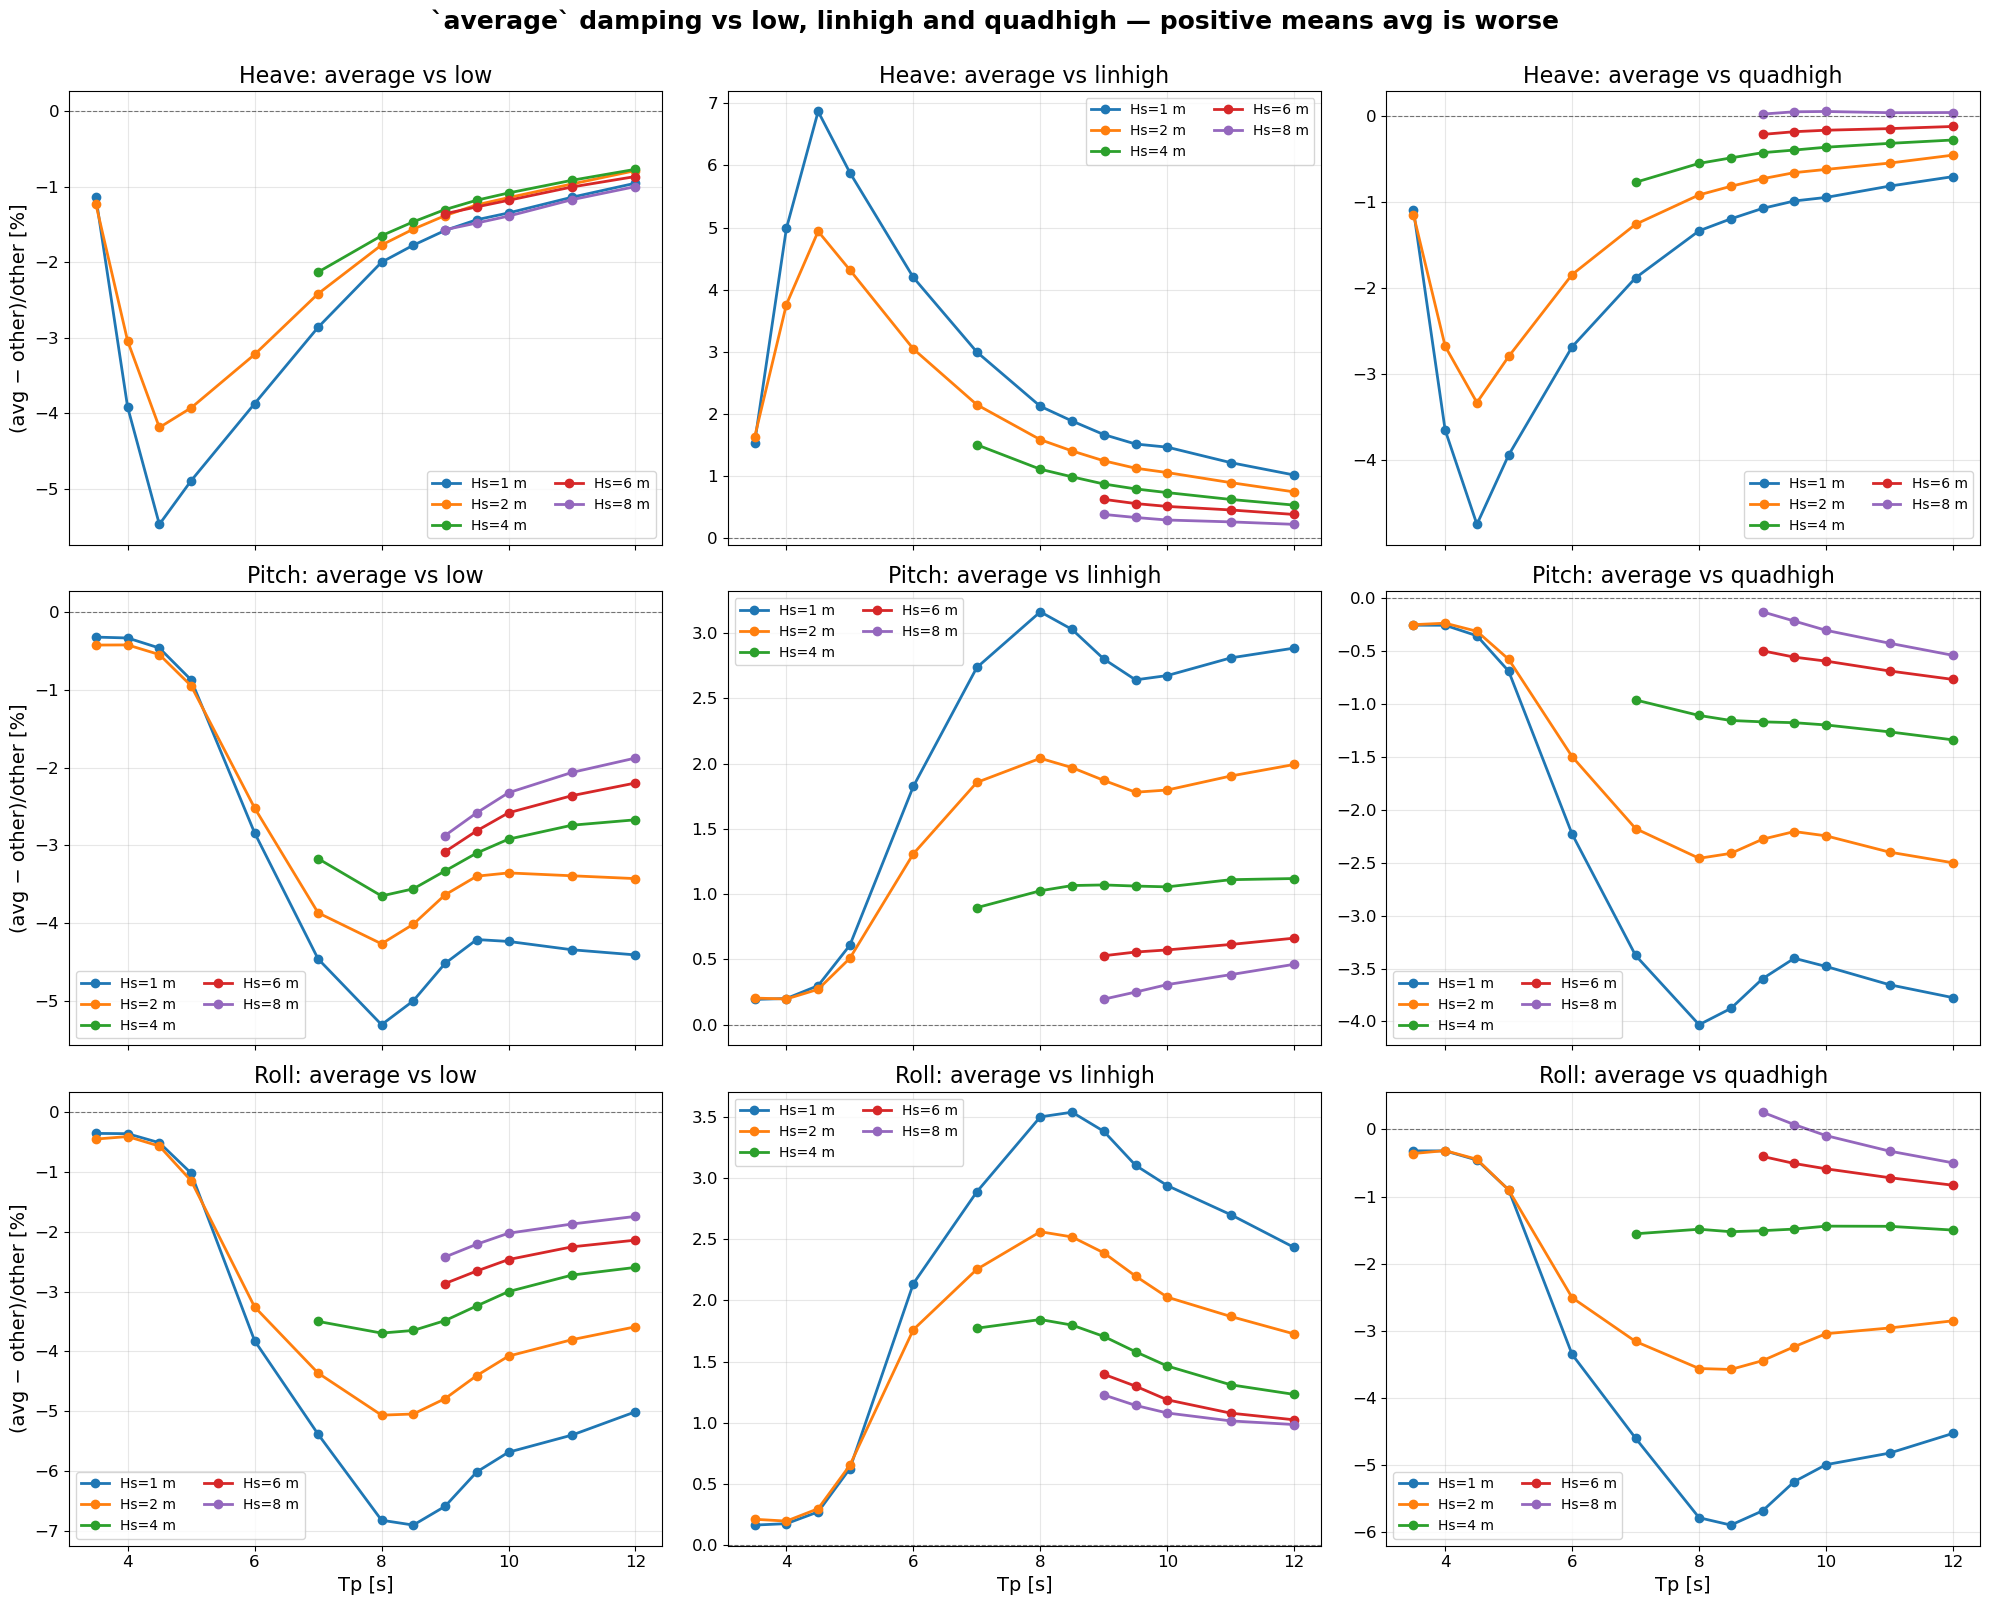

In [12]:
COMPARISONS = ['low', 'linhigh', 'quadhigh']

fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharex=True)

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    pivot = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)
    if 'average' not in pivot.columns:
        continue
    avg = pivot['average']

    for c, other in enumerate(COMPARISONS):
        ax = axes[r, c]
        if other not in pivot.columns:
            ax.set_visible(False)
            continue
        diff_pct = ((avg - pivot[other]) / pivot[other] * 100).rename('diff').reset_index()

        for hs in HS_VALUES:
            s = diff_pct[diff_pct['Hs'] == hs].sort_values('Tp')
            if s.empty:
                continue
            ax.plot(s['Tp'], s['diff'], 'o-', label=f'Hs={hs} m', linewidth=2)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'{dof["name"]}: average vs {other}', fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel('(avg − other)/other [%]', fontsize=LABEL_SIZE)
        ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

fig.suptitle('`average` damping vs low, linhigh and quadhigh — positive means avg is worse',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()